# 14 · Structural cliffs - near-identical structures, opposite outcome (588689)

An **activity cliff** is a pair of nearly identical molecules where one binds and the other does not. They are the sharpest test of what a scoring method actually understands: the structures are almost the same, so any large score difference has to come from a small, specific change - and a method that is blind to that change will score the pair the same.

**Definitions (all on the held-out eval set, so head-FT scores are clean):**
- **Cliff pair:** an active plus a near-identical inactive (ECFP4 Tanimoto >= 0.60).
- **Conserved control:** two near-identical *actives*. Comparing cliffs with controls isolates what is specific to *losing* binding, rather than to being similar.
- **Modalities:** all 9 score columns shipped with the data, plus our No-FT pipeline score and the 5-seed head-FT score. Each is orientation-corrected and turned into a percentile rank over the whole eval set, so deltas are comparable across methods. **Delta = active minus inactive, so positive means that modality ranks the active higher (it 'sees' the cliff).**
- **Confidence:** Boltz-2's own pose confidence read from each pair member's confidence file, plus two-head disagreement and cross-seed spread.
- **Pose:** each member's per-residue minimum distance to the ligand, from its own CIF (frame-independent).
- **Structural cause:** the maximum common substructure of the pair, so the atoms that actually differ are known and can be drawn.

In [1]:

import json, warnings, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")
from IPython.display import display
from scipy import stats
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")
BLK="#000000"; CL="#d62728"; CO="#2a78d6"; NEU="#666666"; GRN="#1baf7a"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); A=ROOT/"results/analysis/588689/cliffs"
P=pd.read_csv(A/"pairs.csv"); M=pd.read_csv(A/"compounds.csv"); Z=np.load(A/"contacts.npz",allow_pickle=True)
AU=pd.read_csv(A/"modality_auroc.csv").set_index("modality")
MODS=[("score_boltz2","Boltz-2 (dataset score)"),("base_noft","Boltz-2 No-FT (our pipeline)"),
      ("ft300","Boltz-2 head-FT N=300 (5-seed)"),("score_boltzina","Boltzina"),
      ("score_boltzina_recycle1","Boltzina recycle-1"),("score_boltzina_mask","Boltzina mask"),
      ("docking_score_boltzina","Boltzina docking (3 identical columns)"),("score_gnina","GNINA"),("score_vina","AutoDock Vina")]
MN=dict(MODS)
CONF=[("ligand_iptm","ligand ipTM (= ipTM here)"),("complex_plddt","complex pLDDT"),("confidence_score","overall confidence"),
      ("complex_pde","complex PDE"),("disagree_noft","two-head disagreement (No-FT)"),("disagree_ft300","two-head disagreement (FT)"),
      ("cross_seed_sd","cross-seed SD (FT)")]
Mi=M.set_index("id"); rng=np.random.default_rng(0)
# ---- orient pairs: a = the ACTIVE member for cliffs; controls (both active) get a random a/b orientation
flip=(P.kind=="conserved")&(rng.random(len(P))<0.5)
swaps=[("id_a","id_b"),("smiles_a","smiles_b"),("diff_a_atoms","diff_b_atoms"),("mcs_a","mcs_b"),("ia","ib")]
swaps+=[(c,"b_"+c[2:]) for c in P.columns if c.startswith("a_") and ("b_"+c[2:]) in P.columns]
for x,y in swaps:
    tmp=P.loc[flip,x].copy(); P.loc[flip,x]=P.loc[flip,y].values; P.loc[flip,y]=tmp.values
def side(col,ids): return Mi[col].reindex(ids).values
for m,_ in MODS: P["d_"+m]=side("pct_"+m,P.id_a)-side("pct_"+m,P.id_b)
for f,_ in CONF: P["c_"+f]=side(f,P.id_a)-side(f,P.id_b)
rowof={i:k for k,i in enumerate(Z["ids"])}; MD=Z["mind"]
ma=MD[[rowof[i] for i in P.id_a]]; mb=MD[[rowof[i] for i in P.id_b]]
ca_,cb_=(ma<=5.0),(mb<=5.0)
inter=(ca_&cb_).sum(1); uni=(ca_|cb_).sum(1)
P["pose_jdist"]=np.where(np.isnan(ma).any(1)|np.isnan(mb).any(1),np.nan,1-inter/np.maximum(uni,1))
P["pose_absdiff"]=np.nanmean(np.abs(ma-mb),axis=1)
PROPS=[("MW","molecular weight"),("heavy","heavy atoms"),("logP","logP"),("TPSA","polar surface area"),("HBD","H-bond donors"),
       ("HBA","H-bond acceptors"),("rotb","rotatable bonds"),("arom_rings","aromatic rings"),("fsp3","fraction sp3")]
for p,_ in PROPS: P["dp_"+p]=P["a_"+p]-P["b_"+p]
_raw=pd.read_csv(ROOT/"data/mf-pcba_test/588689.csv"); ZS=pd.Series(_raw["SD Z-score"].values,index="588689_"+_raw.CID.astype(str))
ACT_Z=ZS[_raw.set_index("588689_"+_raw.CID.astype(str)).target_active_v2==1]; INA_Z=ZS[_raw.set_index("588689_"+_raw.CID.astype(str)).target_active_v2==0]
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
_ids=pd.unique(np.concatenate([P.id_a.values,P.id_b.values])); _ix={k:i for i,k in enumerate(_ids)}
_g=coo_matrix((np.ones(len(P)),([_ix[i] for i in P.id_a],[_ix[i] for i in P.id_b])),shape=(len(_ids),len(_ids)))
_nc,_lab=connected_components(_g,directed=False); P["series"]=[_lab[_ix[i]] for i in P.id_a]
P["simbin"]=pd.cut(P.sim,[0.6,0.7,0.8,1.01],labels=["0.60-0.70","0.70-0.80",">=0.80"],right=False)
_sz=P[P.kind=="cliff"].groupby("series").size().sort_values(ascending=False); BIG=_sz.index[0]; P["big"]=P.series==BIG
CLIFF=P[P.kind=="cliff"].copy(); CTRL=P[P.kind=="conserved"].copy()
def clus_acc(df,col,B=2000,seed=0,neg=False):
    """share of pairs where the signal ranks the active higher (ties = 0.5), 95% CI from resampling chemical SERIES
    (pairs that share an active or sit in the same chemical series are not independent; a series = a connected cluster of pairs)"""
    x=(-df[col] if neg else df[col]).values.astype(float); ids=df["series"].values; ok=np.isfinite(x); x,ids=x[ok],ids[ok]
    if len(x)==0: return np.nan,np.nan,np.nan,0,0
    ind=np.where(x>0,1.0,np.where(x==0,0.5,0.0)); u,inv=np.unique(ids,return_inverse=True)
    sm=np.bincount(inv,weights=ind); n=np.bincount(inv).astype(float)
    idx=np.random.default_rng(seed).integers(0,len(u),(B,len(u))); bs=sm[idx].sum(1)/n[idx].sum(1)
    return sm.sum()/n.sum(),np.percentile(bs,2.5),np.percentile(bs,97.5),int(n.sum()),len(u)
print(f"{P.series.nunique()} independent chemical series (connected clusters of pairs); {CLIFF.series.nunique()} contain a cliff")
print(f"pairs: {len(CLIFF)} cliff (active + inactive), {len(CTRL)} conserved controls (both active); "
      f"{CLIFF.id_a.nunique()} distinct actives have a cliff partner")


94 independent chemical series (connected clusters of pairs); 73 contain a cliff
pairs: 406 cliff (active + inactive), 275 conserved controls (both active); 114 distinct actives have a cliff partner


## Read this first: one chemical series dominates the pairs
Pairs are built all-against-all inside a chemical series, so a big series produces a large number of pairs from few molecules. Nearly everything below is therefore reported three ways: all pairs, without the dominant series, and (where useful) the dominant series alone. Where the answer differs between them, that is stated. p-values in this notebook treat pairs as independent and are optimistic; what to trust is whether the direction and size of an effect hold in both partitions.

dominant series: 252 of 406 cliff pairs (62%) and 79 of 275 control pairs (29%)
it consists of only 52 distinct compounds (18 active, 34 inactive); active share inside it 35% against 0.8% for the library
the other 72 series with a cliff contribute 154 pairs (median 1 pair per series)


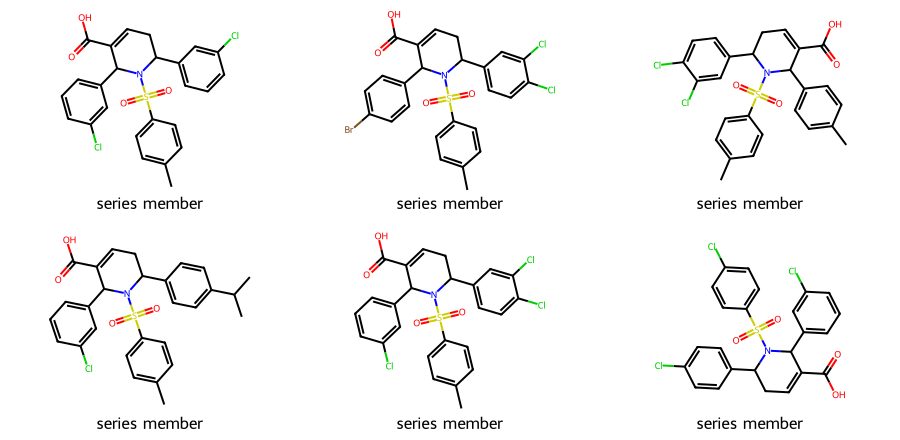

In [2]:
sz=CLIFF.groupby("series").size().sort_values(ascending=False)
mem=pd.unique(np.concatenate([P[P.big].id_a,P[P.big].id_b])); ms=Mi.reindex(mem)
print(f"dominant series: {int(CLIFF.big.sum())} of {len(CLIFF)} cliff pairs ({100*CLIFF.big.mean():.0f}%) and {int(CTRL.big.sum())} of {len(CTRL)} control pairs ({100*CTRL.big.mean():.0f}%)")
print(f"it consists of only {len(mem)} distinct compounds ({int(ms.label.sum())} active, {int((ms.label==0).sum())} inactive); active share inside it {100*ms.label.mean():.0f}% against 0.8% for the library")
print(f"the other {len(sz)-1} series with a cliff contribute {int((~CLIFF.big).sum())} pairs (median {int(sz.iloc[1:].median())} pair per series)")
cs=[m for m in ms.smiles.dropna().head(6)]
display(Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in cs],molsPerRow=3,subImgSize=(300,220),legends=["series member"]*len(cs),returnPNG=False))

## 1. How near-identical are these pairs, and how much actually differs?
Pair similarity and the size of the structural change. Cliffs are not large edits: most differ by a handful of atoms outside a shared core, the same as the conserved controls.

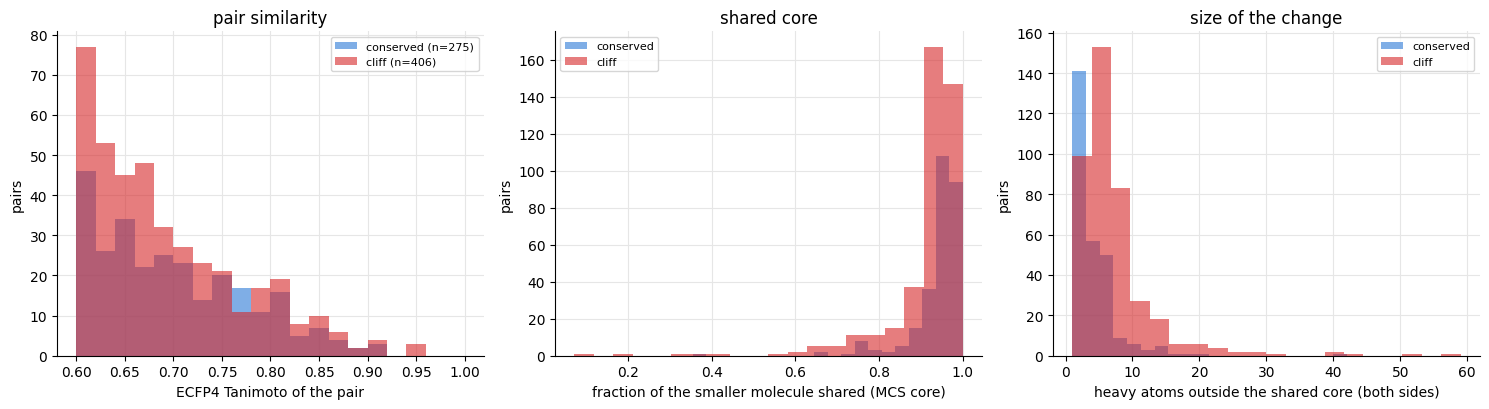

kind,cliff,conserved,share_of_neighbours_that_lose_binding
simbin,,,
0.60-0.70,255,153,0.62
0.70-0.80,99,85,0.54
>=0.80,52,37,0.58


In [3]:
fig,axes=plt.subplots(1,3,figsize=(15,4.2))
bins=np.linspace(0.6,1.0,21)
axes[0].hist(CTRL.sim,bins=bins,color=CO,alpha=0.6,label=f"conserved (n={len(CTRL)})")
axes[0].hist(CLIFF.sim,bins=bins,color=CL,alpha=0.6,label=f"cliff (n={len(CLIFF)})")
axes[0].set_xlabel("ECFP4 Tanimoto of the pair"); axes[0].set_ylabel("pairs"); axes[0].set_title("pair similarity"); axes[0].legend(fontsize=8)
for ax,(col,lab) in zip(axes[1:],[("frac_core","fraction of the smaller molecule shared (MCS core)"),(None,"heavy atoms outside the shared core (both sides)")]):
    for d,c,l in [(CTRL,CO,"conserved"),(CLIFF,CL,"cliff")]:
        v=d[col].dropna() if col else (d.a_diff_n.fillna(0)+d.b_diff_n.fillna(0))[d.mcs_ok==1]
        ax.hist(v,bins=20,color=c,alpha=0.6,label=l)
    ax.set_xlabel(lab); ax.set_ylabel("pairs"); ax.legend(fontsize=8)
axes[1].set_title("shared core"); axes[2].set_title("size of the change")
plt.tight_layout(); plt.show()
tab=P.groupby(["simbin","kind"],observed=True).size().unstack(fill_value=0)
tab["share_of_neighbours_that_lose_binding"]=(tab.get("cliff",0)/(tab.get("cliff",0)+tab.get("conserved",0))).round(2)
display(tab)

## 2. The most identical cliffs, drawn
Pairs ranked by similarity, active on the left and inactive on the right, with the atoms outside the shared core highlighted. Legends give each member's percentile under Boltz-2 (dataset score) and under our head-FT model, so you can see the structural change next to what the models made of it.

Most identical cliff pairs (highlight = atoms outside the shared core)


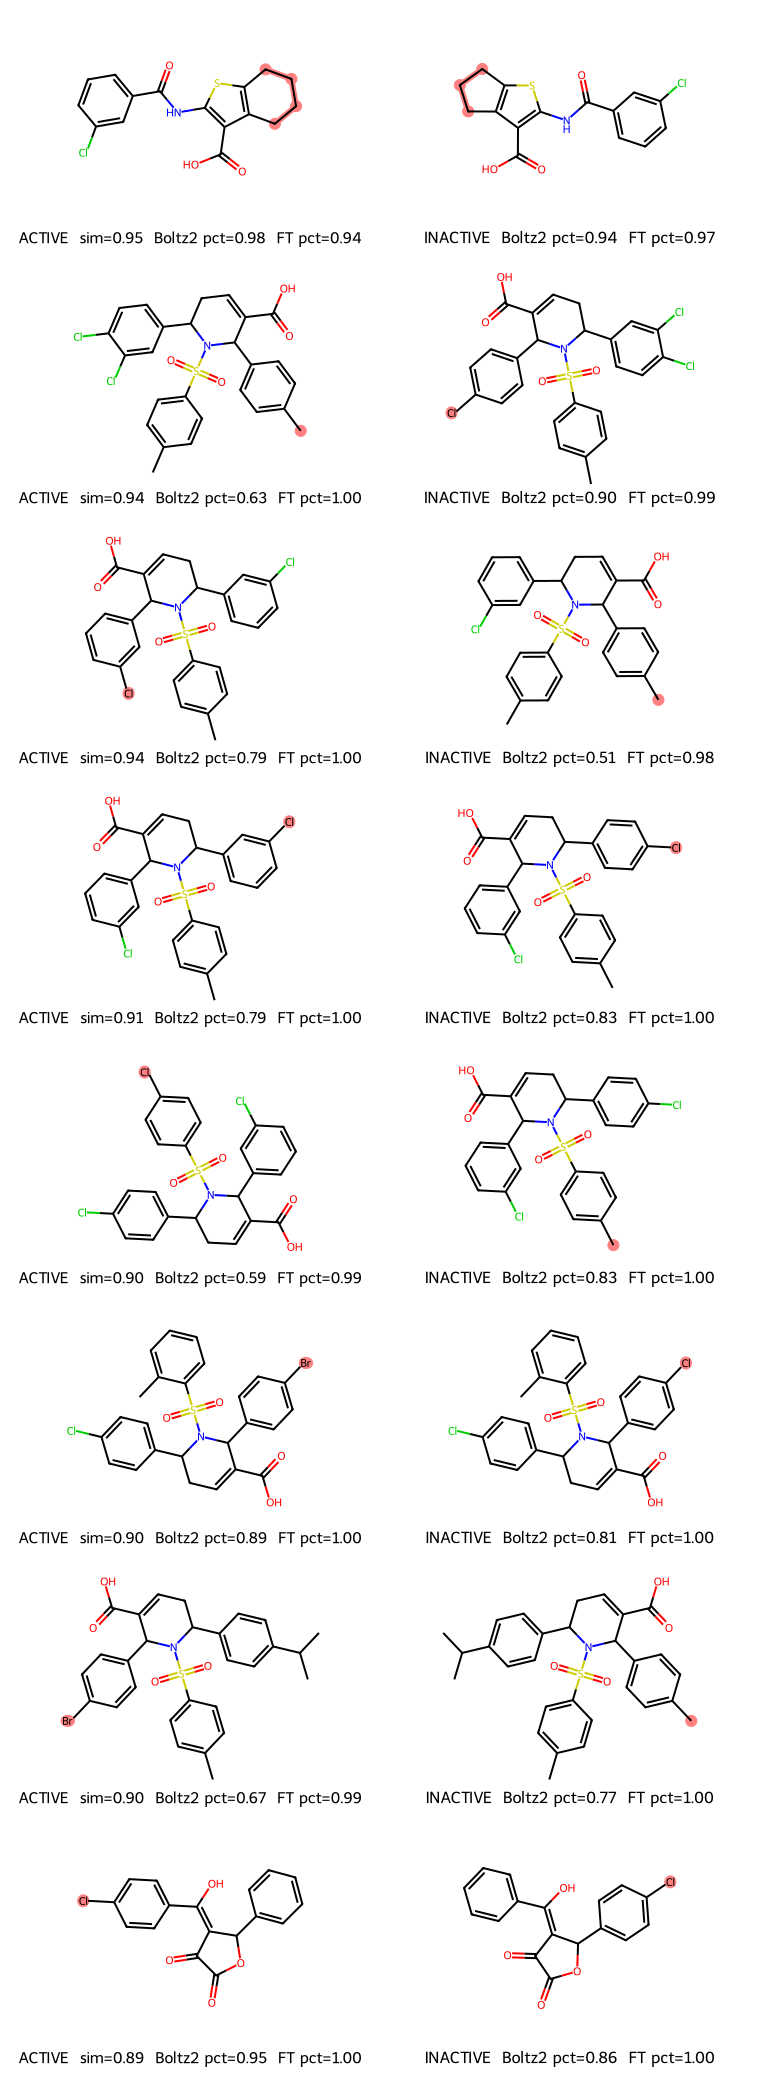

In [4]:
def draw_pairs(df,n=8,title=""):
    mols=[];hl=[];leg=[]
    for _,r in df.head(n).iterrows():
        ma_,mb_=Chem.MolFromSmiles(r.smiles_a),Chem.MolFromSmiles(r.smiles_b)
        if ma_ is None or mb_ is None: continue
        da=json.loads(r.diff_a_atoms) if isinstance(r.diff_a_atoms,str) else []
        db=json.loads(r.diff_b_atoms) if isinstance(r.diff_b_atoms,str) else []
        pa,pb=Mi.pct_score_boltz2.get(r.id_a,np.nan),Mi.pct_score_boltz2.get(r.id_b,np.nan)
        fa,fb=Mi.pct_ft300.get(r.id_a,np.nan),Mi.pct_ft300.get(r.id_b,np.nan)
        mols+= [ma_,mb_]; hl+=[da,db]
        leg+=[f"ACTIVE  sim={r.sim:.2f}  Boltz2 pct={pa:.2f}  FT pct={fa:.2f}",
              f"INACTIVE  Boltz2 pct={pb:.2f}  FT pct={fb:.2f}"]
    if not mols: print("no drawable pairs"); return
    print(title)
    display(Draw.MolsToGridImage(mols,molsPerRow=2,subImgSize=(380,260),legends=leg,highlightAtomLists=hl,returnPNG=False))
top=CLIFF[CLIFF.mcs_ok==1].sort_values(["sim"],ascending=False)
draw_pairs(top,8,"Most identical cliff pairs (highlight = atoms outside the shared core)")

## 3. Which signals can tell a near-identical active from its inactive partner?
For every cliff pair, does a signal rank the active above its inactive partner? 0.5 means blind. Three kinds of signal are compared: **scoring modalities** (green), **Boltz-2 confidence** (grey) and **trivial baselines that use no protein at all** (orange: 'pick the larger molecule', 'pick the more lipophilic one'). The baselines matter because actives here tend to be slightly bigger than their inactive partners, so any method with a size preference will look like it 'sees' the cliff. Intervals are 95% and come from resampling independent *chemical series* (connected clusters of pairs), because many pairs share an active or come from the same combinatorial series. Ties count as half. (The three Boltzina docking columns are byte-identical and ligand ipTM equals ipTM for this single-protein complex, so each is shown once.)

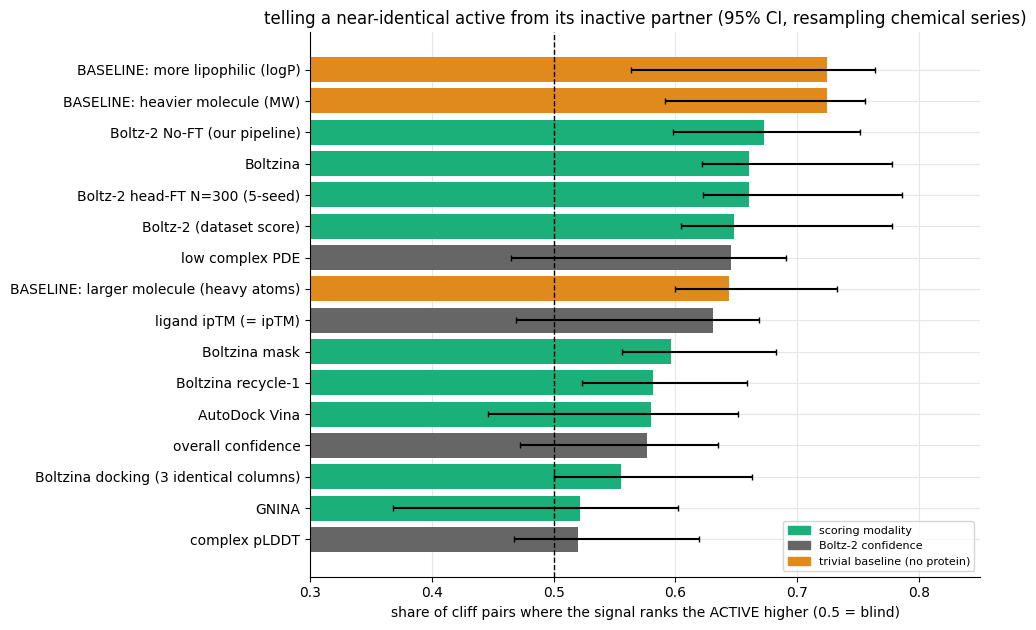

,kind,acc,lo,hi,n_pairs,n_series
signal,,,,,,
complex pLDDT,Boltz-2 confidence,0.520,0.467,0.620,406,73
GNINA,scoring modality,0.522,0.368,0.602,138,25
Boltzina docking (3 identical columns),scoring modality,0.555,0.500,0.663,406,73
overall confidence,Boltz-2 confidence,0.576,0.472,0.635,406,73
AutoDock Vina,scoring modality,0.580,0.446,0.651,138,25
Boltzina recycle-1,scoring modality,0.581,0.523,0.659,406,73
Boltzina mask,scoring modality,0.596,0.556,0.683,406,73
ligand ipTM (= ipTM),Boltz-2 confidence,0.631,0.469,0.668,406,73
BASELINE: larger molecule (heavy atoms),trivial baseline,0.644,0.600,0.732,406,73


In [5]:
rows=[]
for m,l in MODS: rows.append((l,"scoring modality",*clus_acc(CLIFF,"d_"+m)))
for f,l in [("ligand_iptm","ligand ipTM (= ipTM)"),("complex_plddt","complex pLDDT"),("confidence_score","overall confidence")]:
    rows.append((l,"Boltz-2 confidence",*clus_acc(CLIFF,"c_"+f)))
rows.append(("low complex PDE","Boltz-2 confidence",*clus_acc(CLIFF,"c_complex_pde",neg=True)))
rows.append(("BASELINE: larger molecule (heavy atoms)","trivial baseline",*clus_acc(CLIFF,"dp_heavy")))
rows.append(("BASELINE: heavier molecule (MW)","trivial baseline",*clus_acc(CLIFF,"dp_MW")))
rows.append(("BASELINE: more lipophilic (logP)","trivial baseline",*clus_acc(CLIFF,"dp_logP")))
ACC=pd.DataFrame(rows,columns=["signal","kind","acc","lo","hi","n_pairs","n_series"]).sort_values("acc")
colmap={"scoring modality":GRN,"Boltz-2 confidence":NEU,"trivial baseline":"#e08a1e"}
fig,ax=plt.subplots(figsize=(10,6.4))
ax.barh(ACC.signal,ACC.acc,color=[colmap[k] for k in ACC.kind])
ax.errorbar(ACC.acc,range(len(ACC)),xerr=[ACC.acc-ACC.lo,ACC.hi-ACC.acc],fmt="none",ecolor=BLK,capsize=2)
ax.axvline(0.5,ls="--",color=BLK,lw=1); ax.set_xlim(0.3,0.85)
ax.set_xlabel("share of cliff pairs where the signal ranks the ACTIVE higher (0.5 = blind)")
ax.set_title("telling a near-identical active from its inactive partner (95% CI, resampling chemical series)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GRN,label="scoring modality"),Patch(color=NEU,label="Boltz-2 confidence"),Patch(color="#e08a1e",label="trivial baseline (no protein)")],loc="lower right",fontsize=8)
plt.tight_layout(); plt.show(); display(ACC.round(3).set_index("signal"))

**Is the baseline direction fair?** The orange baselines pick 'larger' or 'more lipophilic'. I chose that direction after seeing that actives in these pairs are larger, which would be circular. So here it is checked on the whole library instead: AUROC of each property for the activity label over all ~49.7k eval compounds (0.5 = no trend).

In [6]:
from rdkit.Chem import Descriptors, Crippen
ev=pd.read_csv(A/"scores_eval.csv") if (A/"scores_eval.csv").exists() else None
sm=(ev if ev is not None else _raw.rename(columns={"neut-smiles":"smiles","target_active_v2":"label"}))[["smiles","label"]].dropna()
mols=[Chem.MolFromSmiles(x) for x in sm.smiles]; okm=[m is not None for m in mols]
mw=np.array([Descriptors.MolWt(m) if m else np.nan for m in mols]); ha=np.array([m.GetNumHeavyAtoms() if m else np.nan for m in mols]); lp=np.array([Crippen.MolLogP(m) if m else np.nan for m in mols])
from sklearn.metrics import roc_auc_score
yy=sm.label.values.astype(int)
for nm,v in [("molecular weight",mw),("heavy atoms",ha),("logP",lp)]:
    k=np.isfinite(v); print(f"library-wide AUROC of {nm} for activity: {roc_auc_score(yy[k],v[k]):.3f}")
print("(>0.5 means larger / greasier compounds are more often active across the whole library, independent of these pairs)")

library-wide AUROC of molecular weight for activity: 0.593
library-wide AUROC of heavy atoms for activity: 0.586
library-wide AUROC of logP for activity: 0.655
(>0.5 means larger / greasier compounds are more often active across the whole library, independent of these pairs)


## 3b. How much of that is just size?
The same accuracy, split by whether the active is larger than, the same size as, or smaller than its inactive partner. If a signal 'understands' the change it should hold up in every row. If it only prefers bigger molecules it will fall to chance when the active is the smaller one.

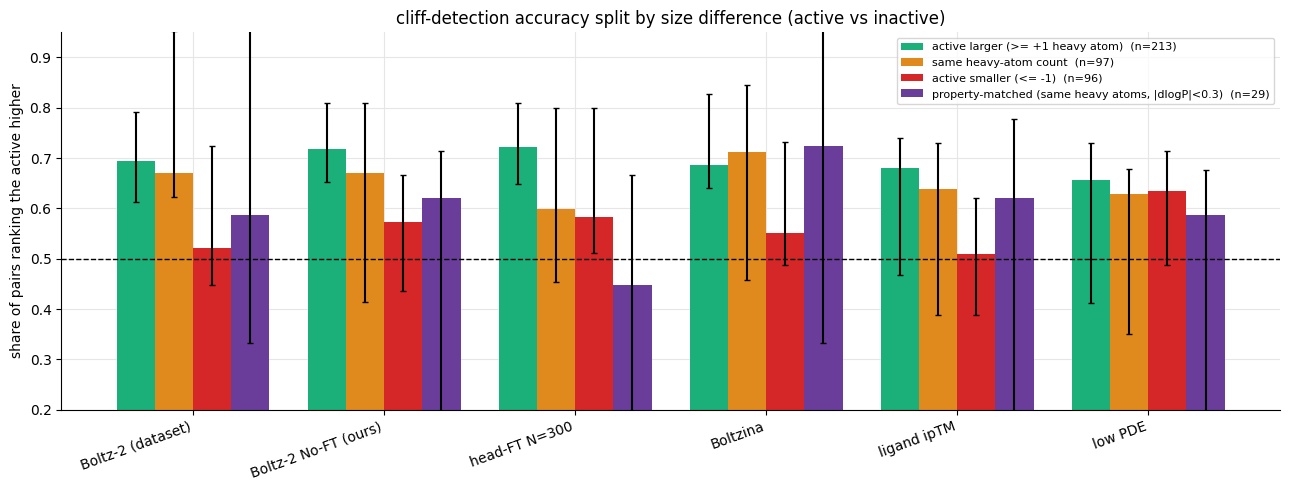

,pairs,Boltz-2 (dataset),Boltz-2 No-FT (ours),head-FT N=300,Boltzina,ligand ipTM,low PDE
stratum,,,,,,,
active larger (>= +1 heavy atom),213,0.69,0.72,0.72,0.69,0.68,0.66
same heavy-atom count,97,0.67,0.67,0.60,0.71,0.64,0.63
active smaller (<= -1),96,0.52,0.57,0.58,0.55,0.51,0.64
"property-matched (same heavy atoms, |dlogP|<0.3)",29,0.59,0.62,0.45,0.72,0.62,0.59


Spearman(ligand ipTM difference, heavy-atom difference) within cliffs: rho=0.14 p=0.0035


In [7]:
SIGS=[("Boltz-2 (dataset)","d_score_boltz2",False),("Boltz-2 No-FT (ours)","d_base_noft",False),("head-FT N=300","d_ft300",False),
      ("Boltzina","d_score_boltzina",False),("ligand ipTM","c_ligand_iptm",False),("low PDE","c_complex_pde",True)]
STR=[("active larger (>= +1 heavy atom)",CLIFF.dp_heavy>=1),("same heavy-atom count",CLIFF.dp_heavy==0),("active smaller (<= -1)",CLIFF.dp_heavy<=-1),("property-matched (same heavy atoms, |dlogP|<0.3)",(CLIFF.dp_heavy==0)&(CLIFF.dp_logP.abs()<0.3))]
fig,ax=plt.subplots(figsize=(13,5)); w=0.2; x=np.arange(len(SIGS)); cs=[GRN,"#e08a1e",CL,"#6a3d9a"]; out=[]
for k,(sn,mask) in enumerate(STR):
    sub=CLIFF[mask]; r=[clus_acc(sub,c,neg=ng) for _,c,ng in SIGS]
    ax.bar(x+(k-1.5)*w,[v[0] for v in r],w,color=cs[k],label=f"{sn}  (n={len(sub)})")
    ax.errorbar(x+(k-1.5)*w,[v[0] for v in r],yerr=[[v[0]-v[1] for v in r],[v[2]-v[0] for v in r]],fmt="none",ecolor=BLK,capsize=2)
    out.append((sn,len(sub),*[round(v[0],2) for v in r]))
ax.axhline(0.5,ls="--",color=BLK,lw=1); ax.set_xticks(x); ax.set_xticklabels([s for s,_,_ in SIGS],rotation=20,ha="right")
ax.set_ylabel("share of pairs ranking the active higher"); ax.set_ylim(0.2,0.95); ax.legend(fontsize=8)
ax.set_title("cliff-detection accuracy split by size difference (active vs inactive)"); plt.tight_layout(); plt.show()
display(pd.DataFrame(out,columns=["stratum","pairs"]+[s for s,_,_ in SIGS]).set_index("stratum"))
print("Spearman(ligand ipTM difference, heavy-atom difference) within cliffs: rho=%.2f p=%.2g"%stats.spearmanr(CLIFF.c_ligand_iptm,CLIFF.dp_heavy,nan_policy="omit"))

## 3c. Are a few big chemical series driving this?
Pairs are not independent draws: combinatorial series contribute many pairs. Here is how concentrated the cliffs are, and the same accuracies with the single largest series removed.

In [8]:
sz=CLIFF.groupby("series").size().sort_values(ascending=False)
print(f"{len(sz)} series contain a cliff; pairs per series: largest {sz.iloc[0]}, top-3 {int(sz.iloc[:3].sum())} = {100*sz.iloc[:3].sum()/len(CLIFF):.0f}% of {len(CLIFF)} cliff pairs; median {int(sz.median())}")
rest=CLIFF[CLIFF.series!=sz.index[0]]; rows=[]
for nm,c,ng in [("Boltz-2 (dataset)","d_score_boltz2",False),("Boltz-2 No-FT (ours)","d_base_noft",False),("head-FT N=300","d_ft300",False),("Boltzina","d_score_boltzina",False),
                ("ligand ipTM","c_ligand_iptm",False),("low PDE","c_complex_pde",True),("BASELINE larger molecule","dp_heavy",False),("BASELINE more lipophilic","dp_logP",False),("BASELINE heavier","dp_MW",False)]:
    a=clus_acc(CLIFF,c,neg=ng); b=clus_acc(rest,c,neg=ng); rows.append((nm,a[0],b[0],b[3]))
display(pd.DataFrame(rows,columns=["signal","all cliff pairs","without the largest series","pairs left"]).set_index("signal").round(3))

73 series contain a cliff; pairs per series: largest 252, top-3 282 = 69% of 406 cliff pairs; median 1


,all cliff pairs,without the largest series,pairs left
signal,,,
Boltz-2 (dataset),0.648,0.688,154
Boltz-2 No-FT (ours),0.672,0.669,154
head-FT N=300,0.660,0.701,154
Boltzina,0.660,0.701,154
ligand ipTM,0.631,0.565,154
low PDE,0.645,0.539,154
BASELINE larger molecule,0.644,0.672,154
BASELINE more lipophilic,0.724,0.640,154
BASELINE heavier,0.724,0.672,154


## 4. Pair by pair (heatmap)
Rows are cliff pairs (most identical first), columns are modalities, colour is the percentile delta (active minus inactive). Blue means the modality ranks the active higher; red means it prefers the inactive partner.

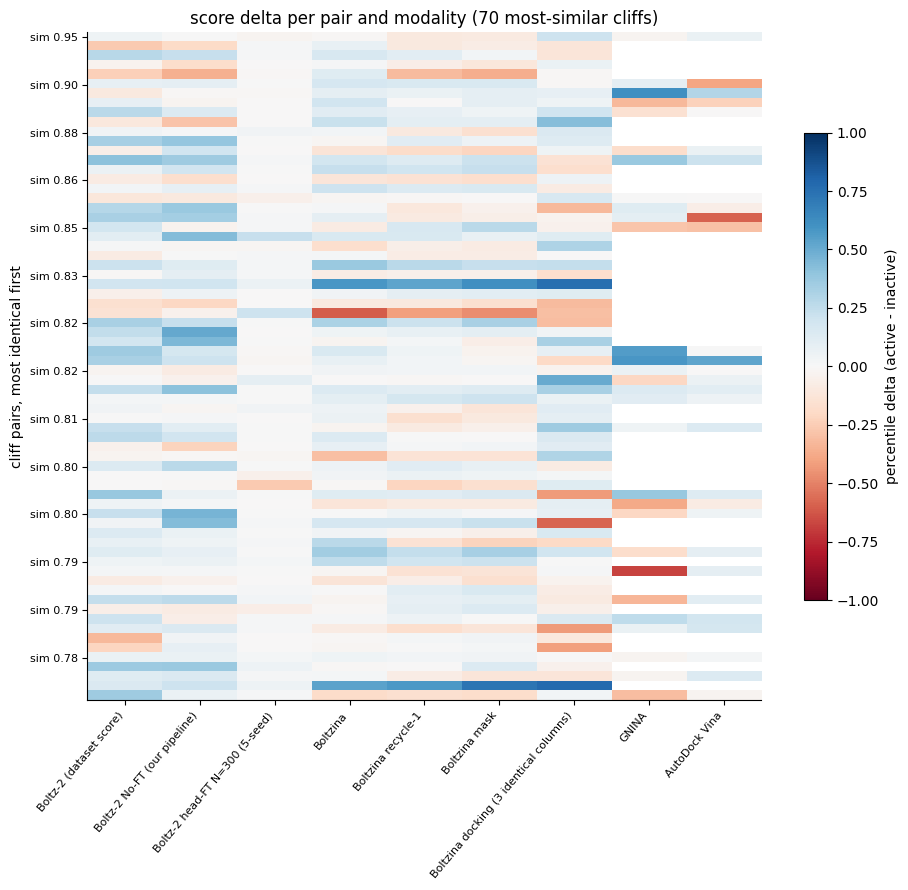

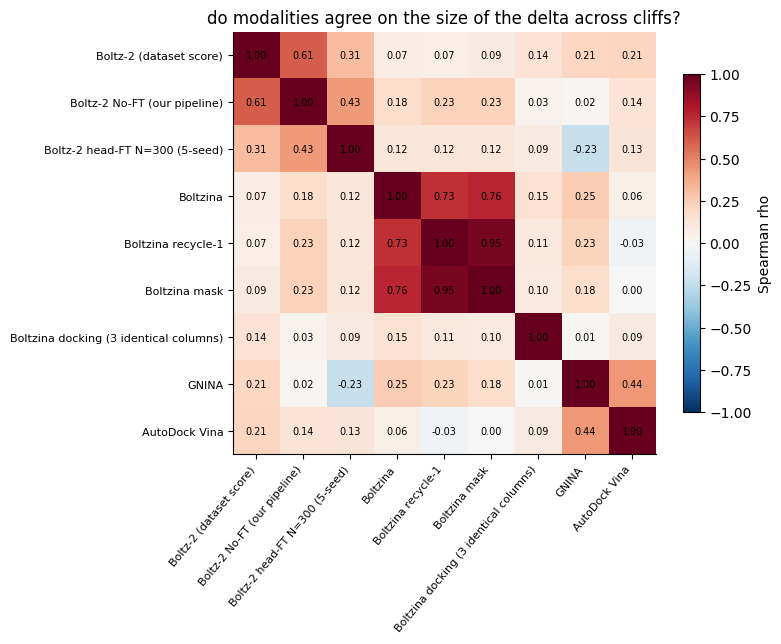

In [9]:
H=CLIFF.sort_values("sim",ascending=False).head(70)
Dm=H[["d_"+m for m,_ in MODS]].values
fig,ax=plt.subplots(figsize=(9.5,9)); im=ax.imshow(Dm,aspect="auto",cmap="RdBu",vmin=-1,vmax=1,interpolation="nearest")
ax.set_xticks(range(len(MODS))); ax.set_xticklabels([l for _,l in MODS],rotation=50,ha="right",fontsize=8)
ax.set_yticks(range(0,len(H),5)); ax.set_yticklabels([f"sim {s:.2f}" for s in H.sim.values[::5]],fontsize=8)
ax.set_ylabel("cliff pairs, most identical first"); ax.grid(False)
fig.colorbar(im,ax=ax,shrink=0.7,label="percentile delta (active - inactive)")
ax.set_title("score delta per pair and modality (70 most-similar cliffs)"); plt.tight_layout(); plt.show()
cm=CLIFF[["d_"+m for m,_ in MODS]].rename(columns={"d_"+m:l for m,l in MODS}).corr(method="spearman")
fig,ax=plt.subplots(figsize=(8,6.5)); im=ax.imshow(cm.values,cmap="RdBu_r",vmin=-1,vmax=1); ax.grid(False)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns,rotation=50,ha="right",fontsize=8); ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index,fontsize=8)
for i in range(len(cm)):
    for j in range(len(cm)): ax.text(j,i,f"{cm.values[i,j]:.2f}",ha="center",va="center",fontsize=7)
fig.colorbar(im,ax=ax,shrink=0.8,label="Spearman rho"); ax.set_title("do modalities agree on the size of the delta across cliffs?"); plt.tight_layout(); plt.show()

## 5. Where are the big deltas? Similarity vs score delta
Each point is a cliff pair. Above zero the modality ranks the active higher; below zero it prefers the inactive partner. Counts are for near-identical pairs (Tanimoto >= 0.7) with |delta| > 0.3 of a percentile.

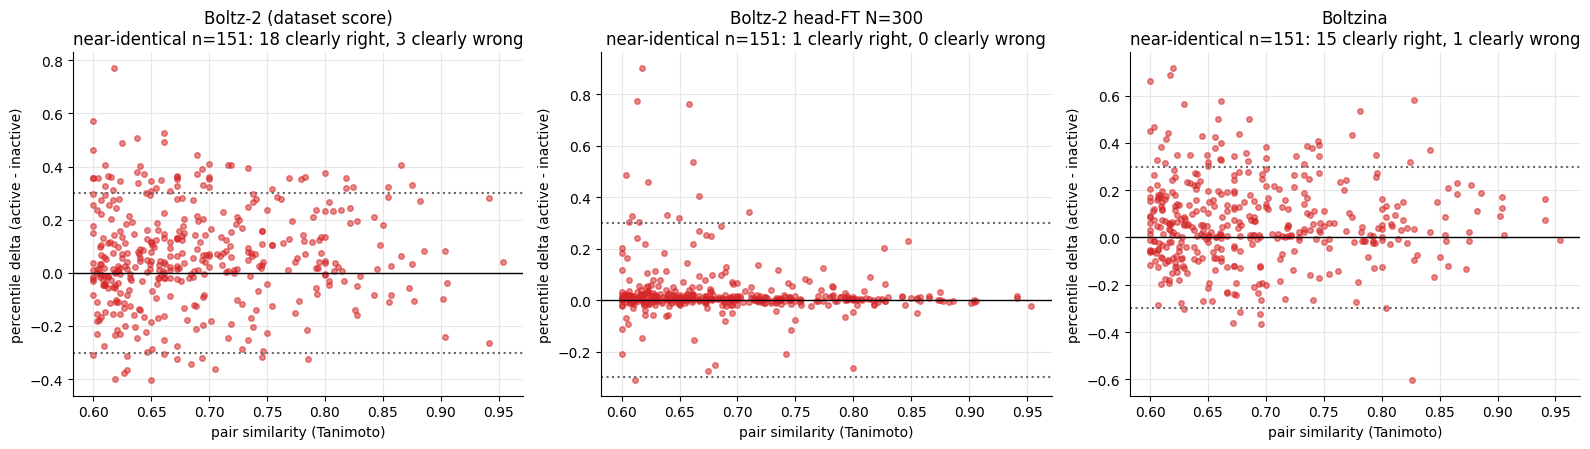

all cliff pairs


,near-identical pairs,clearly right (>+0.3),near tie,clearly wrong (<-0.3)
modality,,,,
Boltz-2 (dataset score),151,18,130,3
Boltz-2 No-FT (our pipeline),151,26,119,6
Boltz-2 head-FT N=300 (5-seed),151,1,150,0
Boltzina,151,15,135,1
Boltzina recycle-1,151,6,138,7
Boltzina mask,151,8,137,6
Boltzina docking (3 identical columns),151,25,110,16
GNINA,54,12,35,7
AutoDock Vina,54,6,45,3


without the dominant series


,near-identical pairs,clearly right (>+0.3),near tie,clearly wrong (<-0.3)
modality,,,,
Boltz-2 (dataset score),48,1,47,0
Boltz-2 No-FT (our pipeline),48,2,45,1
Boltz-2 head-FT N=300 (5-seed),48,1,47,0
Boltzina,48,7,40,1
Boltzina recycle-1,48,5,41,2
Boltzina mask,48,6,41,1
Boltzina docking (3 identical columns),48,8,38,2
GNINA,13,0,11,2
AutoDock Vina,13,1,12,0


dominant series only


,near-identical pairs,clearly right (>+0.3),near tie,clearly wrong (<-0.3)
modality,,,,
Boltz-2 (dataset score),103,17,83,3
Boltz-2 No-FT (our pipeline),103,24,74,5
Boltz-2 head-FT N=300 (5-seed),103,0,103,0
Boltzina,103,8,95,0
Boltzina recycle-1,103,1,97,5
Boltzina mask,103,2,96,5
Boltzina docking (3 identical columns),103,17,72,14
GNINA,41,12,24,5
AutoDock Vina,41,5,33,3


In [10]:
fig,axes=plt.subplots(1,3,figsize=(16,4.6)); summ=[]
for ax,(m,l) in zip(axes,[("score_boltz2","Boltz-2 (dataset score)"),("ft300","Boltz-2 head-FT N=300"),("score_boltzina","Boltzina")]):
    d=CLIFF[["sim","d_"+m]].dropna(); ax.scatter(d.sim,d["d_"+m],s=16,alpha=0.55,color=CL)
    ax.axhline(0,color=BLK,lw=1); ax.axhline(0.3,ls=":",color=NEU); ax.axhline(-0.3,ls=":",color=NEU)
    near=d[d.sim>=0.7]; bad=(near["d_"+m]<-0.3).sum(); good=(near["d_"+m]>0.3).sum()
    ax.set_xlabel("pair similarity (Tanimoto)"); ax.set_ylabel("percentile delta (active - inactive)")
    ax.set_title(f"{l}\nnear-identical n={len(near)}: {good} clearly right, {bad} clearly wrong")
plt.tight_layout(); plt.show()
def near_tab(d):
    out=[]
    for m,l in MODS:
        near=d[d.sim>=0.7]["d_"+m].dropna()
        out.append((l,len(near),int((near>0.3).sum()),int((near.abs()<=0.3).sum()),int((near<-0.3).sum())))
    return pd.DataFrame(out,columns=["modality","near-identical pairs","clearly right (>+0.3)","near tie","clearly wrong (<-0.3)"]).set_index("modality")
for nm,d in [("all cliff pairs",CLIFF),("without the dominant series",CLIFF[~CLIFF.big]),("dominant series only",CLIFF[CLIFF.big])]:
    print(nm); display(near_tab(d))

Near-identical cliffs where Boltz-2 most prefers the INACTIVE partner (largest wrong-way delta)


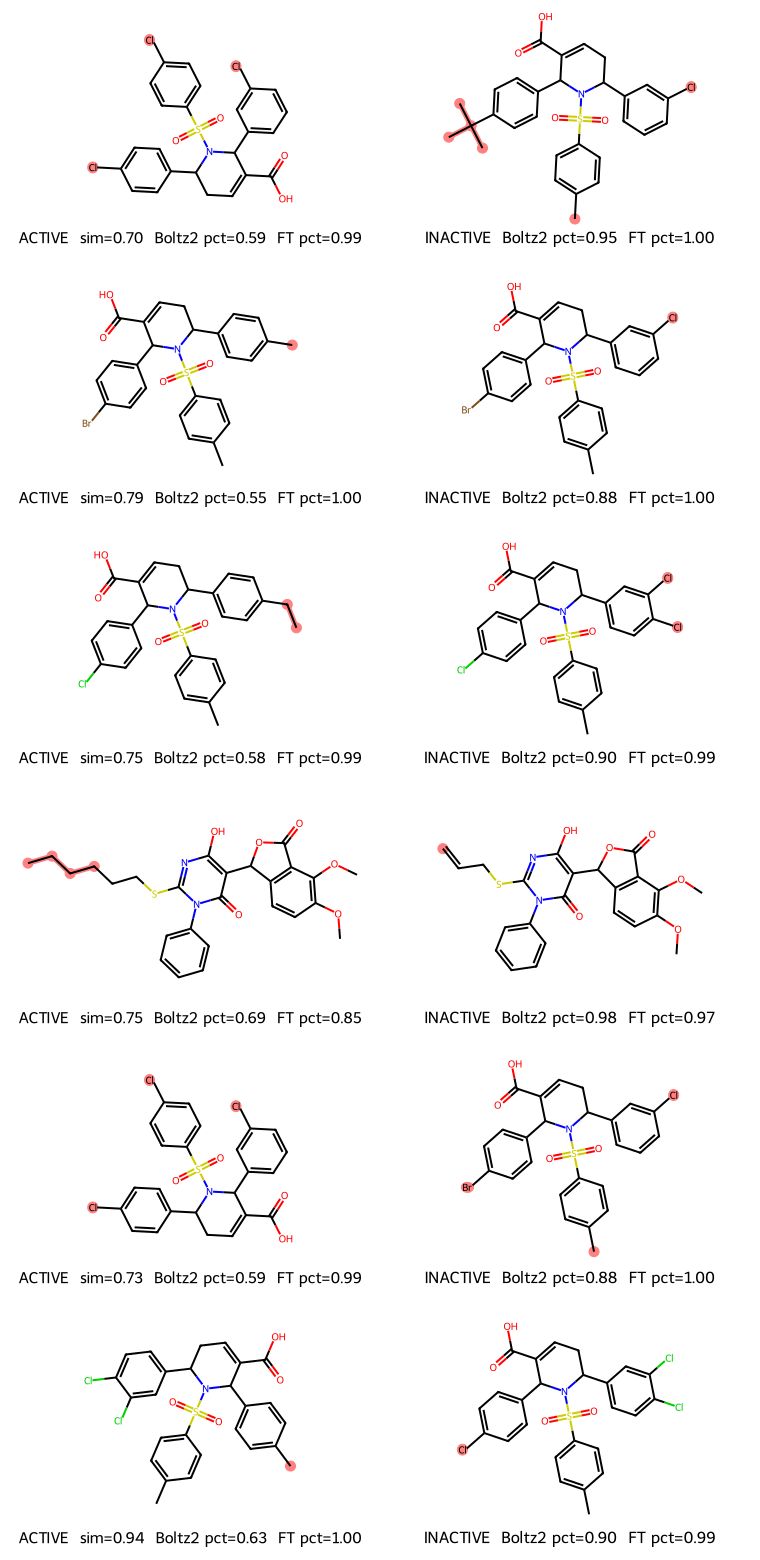

In [11]:
fooled=CLIFF[(CLIFF.sim>=0.7)&(CLIFF.mcs_ok==1)].sort_values("d_score_boltz2")
draw_pairs(fooled,6,"Near-identical cliffs where Boltz-2 most prefers the INACTIVE partner (largest wrong-way delta)")

## 6. How complete is the loss of binding?
'Inactive' in a screen is a threshold on a noisy readout. The data include each compound's primary-screen Z-score, so we can ask whether the inactive partners are clean zeros or partly active. Each distinct inactive partner is counted once: many pairs share a partner, and counting per pair would let the dominant series carry most of the weight.

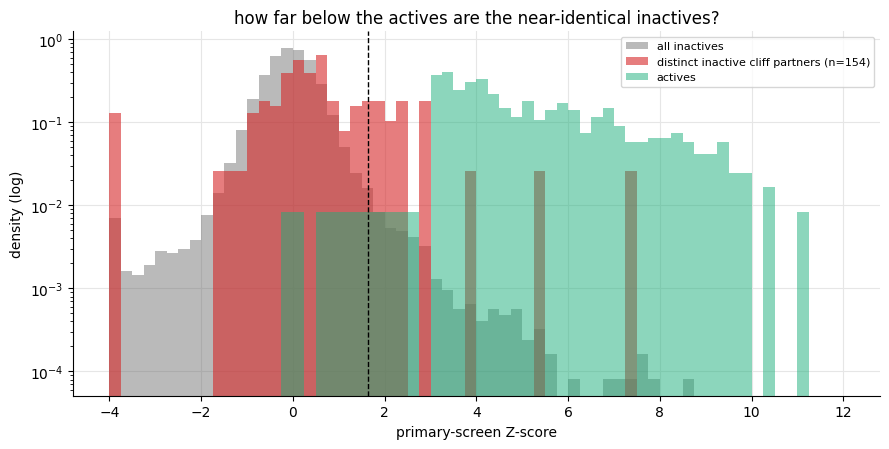

median Z: actives 4.53 | all inactives -0.05 | distinct cliff partners 0.45
partners above the 99th percentile of ordinary inactives (Z>1.63): 19%   (ordinary inactives: 1% by definition)
partners at/above the weakest 10% of actives (Z>=3.19): 1.9%
do the models rank partners with a higher screen readout higher? (compound level, Spearman of partner Z vs partner percentile)
  all partners                 n=154  Boltz-2 dataset  rho=+0.04 (p=0.6)
  all partners                 n=154  head-FT          rho=+0.18 (p=0.029)
  without the dominant series  n=120  Boltz-2 dataset  rho=+0.17 (p=0.072)
  without the dominant series  n=120  head-FT          rho=+0.05 (p=0.58)
  dominant series only         n= 34  Boltz-2 dataset  rho=-0.21 (p=0.22)
  dominant series only         n= 34  head-FT          rho=+0.33 (p=0.056)


In [12]:
part_ids=pd.unique(CLIFF.id_b); big_part=set(CLIFF[CLIFF.big].id_b); partZ=ZS.reindex(part_ids).dropna(); hi99=INA_Z.quantile(0.99)
fig,ax=plt.subplots(figsize=(9,4.6)); bins=np.linspace(-4,12,65)
ax.hist(INA_Z.clip(-4,12),bins=bins,density=True,color=NEU,alpha=0.45,label="all inactives")
ax.hist(partZ.clip(-4,12),bins=bins,density=True,color=CL,alpha=0.6,label=f"distinct inactive cliff partners (n={len(partZ)})")
ax.hist(ACT_Z.clip(-4,12),bins=bins,density=True,color=GRN,alpha=0.5,label="actives"); ax.set_yscale("log")
ax.axvline(hi99,ls="--",color=BLK,lw=1); ax.set_xlabel("primary-screen Z-score"); ax.set_ylabel("density (log)"); ax.legend(fontsize=8)
ax.set_title("how far below the actives are the near-identical inactives?"); plt.tight_layout(); plt.show()
print(f"median Z: actives {ACT_Z.median():.2f} | all inactives {INA_Z.median():.2f} | distinct cliff partners {partZ.median():.2f}")
print(f"partners above the 99th percentile of ordinary inactives (Z>{hi99:.2f}): {100*(partZ>hi99).mean():.0f}%   (ordinary inactives: 1% by definition)")
print(f"partners at/above the weakest 10% of actives (Z>={ACT_Z.quantile(0.1):.2f}): {100*(partZ>=ACT_Z.quantile(0.1)).mean():.1f}%")
print("do the models rank partners with a higher screen readout higher? (compound level, Spearman of partner Z vs partner percentile)")
for nm,ids in [("all partners",list(part_ids)),("without the dominant series",[i for i in part_ids if i not in big_part]),("dominant series only",[i for i in part_ids if i in big_part])]:
    z=ZS.reindex(ids)
    for m,l in [("pct_score_boltz2","Boltz-2 dataset"),("pct_ft300","head-FT")]:
        v=Mi[m].reindex(ids); ok=(z.notna()&v.notna()).values; r,p=stats.spearmanr(z[ok],v[ok])
        print(f"  {nm:<28} n={int(ok.sum()):>3}  {l:<16} rho={r:+.2f} (p={p:.2g})")

## 6b. Are the top-of-ranking false positives just siblings of true actives?
The ranking is judged on its top 1%. For each model, take the inactive compounds in its top 1% (the false positives) and ask what share are near-identical to a true active (a cliff partner: Tanimoto >= 0.6 to an eval active). Compare with how common cliff partners are among ordinary compounds. If the false positives at the top are mostly siblings of actives, then cliffs are a direct cause of lost early enrichment.

,top 1% size,true actives in it,false positives,cliff-sibling false positives,of which in the dominant series,% of false positives,enrichment vs ordinary compounds (x),% without the dominant series
model,,,,,,,,
Boltz-2 No-FT (our pipeline),497,67,430,8,0,1.86,6.00,1.86
Boltz-2 head-FT N=300,497,125,372,29,14,7.80,25.15,4.03
Boltz-2 (dataset score),497,73,424,10,0,2.36,7.61,2.36


ordinary compounds that are a cliff partner of an eval active: 0.31%


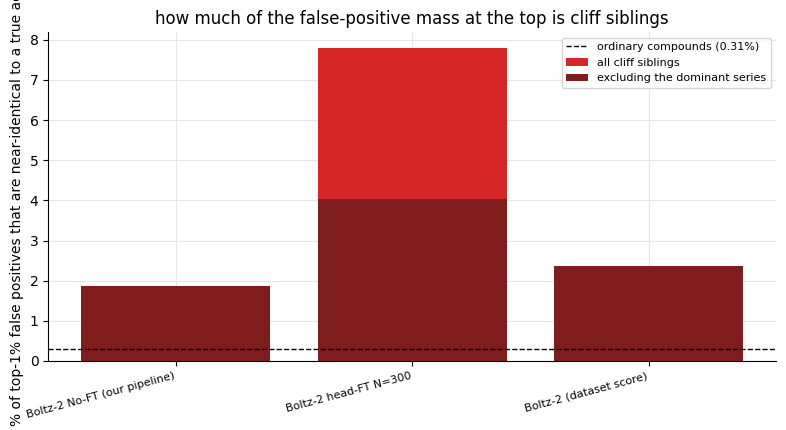

In [13]:
ev=pd.read_csv(A/"scores_eval.csv"); partner_ids=set(CLIFF.id_b); big_ids=set(CLIFF[CLIFF.big].id_b); k=int(round(0.01*len(ev)))
base_rate=ev.id.isin(partner_ids).mean(); rows=[]
for m,l in [("base_noft","Boltz-2 No-FT (our pipeline)"),("ft300","Boltz-2 head-FT N=300"),("score_boltz2","Boltz-2 (dataset score)")]:
    top=ev.nlargest(k,m); fp=top[top.label==0]; tp=top[top.label==1]; sib=fp.id.isin(partner_ids)
    rows.append((l,k,len(tp),len(fp),int(sib.sum()),int(fp.id.isin(big_ids).sum()),100*sib.mean(),sib.mean()/base_rate,100*(sib.sum()-fp.id.isin(big_ids).sum())/len(fp)))
T6=pd.DataFrame(rows,columns=["model","top 1% size","true actives in it","false positives","cliff-sibling false positives","of which in the dominant series","% of false positives","enrichment vs ordinary compounds (x)","% without the dominant series"]).set_index("model")
display(T6.round(2)); print(f"ordinary compounds that are a cliff partner of an eval active: {100*base_rate:.2f}%")
fig,ax=plt.subplots(figsize=(8,4.4)); ax.bar(range(len(T6)),T6["% of false positives"],color=CL,label="all cliff siblings"); ax.bar(range(len(T6)),T6["% without the dominant series"],color="#7f1d1d",label="excluding the dominant series")
ax.axhline(100*base_rate,ls="--",color=BLK,lw=1,label=f"ordinary compounds ({100*base_rate:.2f}%)")
ax.set_xticks(range(len(T6))); ax.set_xticklabels(T6.index,rotation=15,ha="right",fontsize=8); ax.set_ylabel("% of top-1% false positives that are near-identical to a true active")
ax.legend(fontsize=8); ax.set_title("how much of the false-positive mass at the top is cliff siblings"); plt.tight_layout(); plt.show()

## 7. Why: what chemically differs in the pairs that lose binding?
Property change (active minus inactive) for cliff pairs, next to the control (both active, random orientation, so it centres on zero by construction). Only the cliff-versus-zero test is informative about direction; the |delta| test asks whether cliff pairs change more than control pairs. SMILES here are neutralised, so net charge carries no information and is omitted.

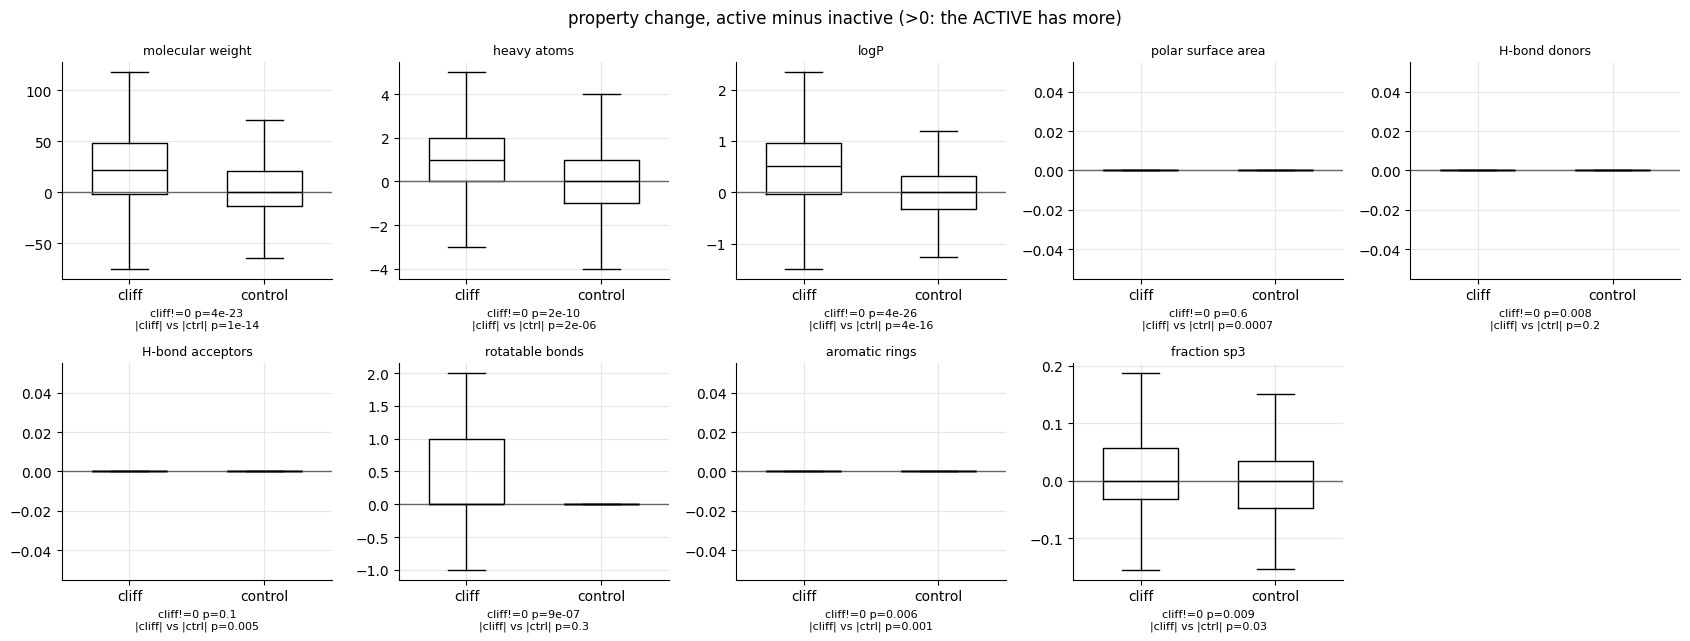

,"median delta (active-inactive), cliffs",share of cliffs where active has MORE,share where active has FEWER,p (delta != 0),p (|delta| cliff vs control)
property,,,,,
molecular weight,22.0755,0.7143,0.2660,0.0000,0.0000
heavy atoms,1.0000,0.5246,0.2365,0.0000,0.0000
logP,0.5049,0.7143,0.2660,0.0000,0.0000
polar surface area,0.0000,0.1502,0.1798,0.5707,0.0007
H-bond donors,0.0000,0.0665,0.0271,0.0085,0.2386
H-bond acceptors,0.0000,0.1084,0.1897,0.1273,0.0049
rotatable bonds,0.0000,0.3128,0.1552,0.0000,0.3135
aromatic rings,0.0000,0.0714,0.0271,0.0058,0.0011
fraction sp3,0.0000,0.4187,0.3645,0.0091,0.0260


In [14]:
fig,axes=plt.subplots(2,5,figsize=(17,6.5)); res=[]
for ax,(p,l) in zip(axes.ravel(),PROPS):
    a=CLIFF["dp_"+p].dropna(); b=CTRL["dp_"+p].dropna()
    ax.boxplot([a,b],tick_labels=["cliff","control"],showfliers=False,widths=0.55,medianprops=dict(color=BLK))
    ax.axhline(0,color=NEU,lw=1); ax.set_title(l,fontsize=9)
    try: pz_=stats.wilcoxon(a).pvalue
    except Exception: pz_=np.nan
    pu=stats.mannwhitneyu(a.abs(),b.abs()).pvalue
    ax.set_xlabel(f"cliff!=0 p={pz_:.1g}\n|cliff| vs |ctrl| p={pu:.1g}",fontsize=8); res.append((l,a.median(),(a>0).mean(),(a<0).mean(),pz_,pu))
for ax in axes.ravel()[len(PROPS):]: ax.axis("off")
fig.suptitle("property change, active minus inactive (>0: the ACTIVE has more)",fontsize=12); plt.tight_layout(); plt.show()
display(pd.DataFrame(res,columns=["property","median delta (active-inactive), cliffs","share of cliffs where active has MORE","share where active has FEWER","p (delta != 0)","p (|delta| cliff vs control)"]).set_index("property").round(4))

## 8. The changed fragment itself, and the loss rate by kind of change
Only the atoms outside the shared core. The right panel is the loss rate: of an active's near-identical neighbours, what fraction lose binding, split by the kind of change.

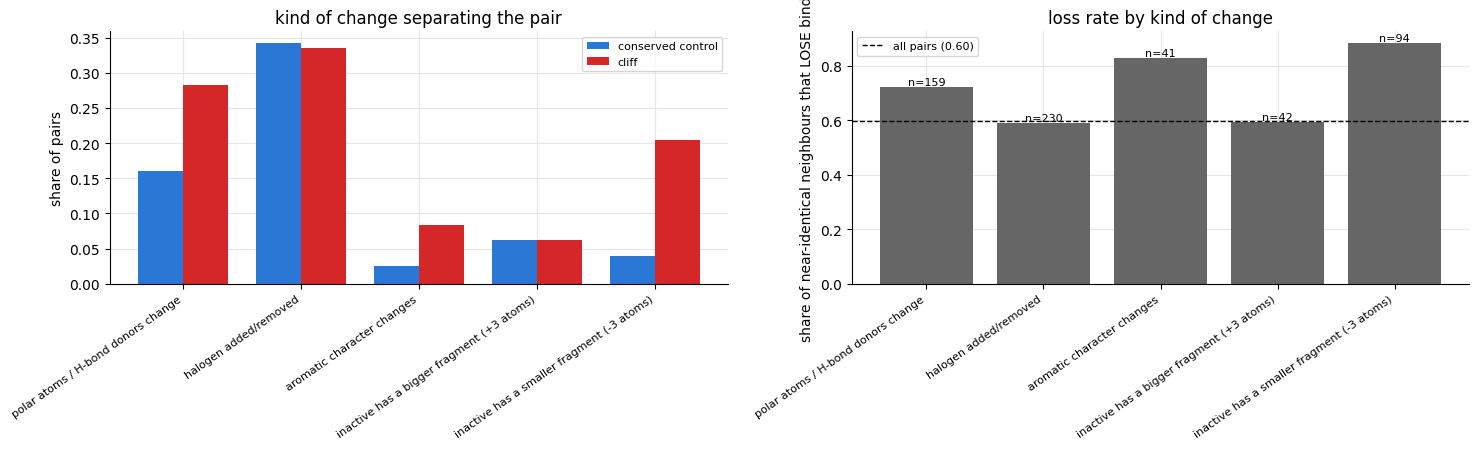

In [15]:
C2=P[(P.mcs_ok==1)].copy()
C2["polar_diff"]=(C2.a_diff_hbd!=C2.b_diff_hbd)|((C2.a_diff_has_N+C2.a_diff_has_O)!=(C2.b_diff_has_N+C2.b_diff_has_O))
C2["hal_diff"]=(C2.a_diff_has_hal!=C2.b_diff_has_hal); C2["arom_diff"]=(C2.a_diff_arom!=C2.b_diff_arom)
C2["size_gain"]=(C2.b_diff_n-C2.a_diff_n); C2["bigger_inactive"]=C2.size_gain>=3; C2["smaller_inactive"]=C2.size_gain<=-3
flags8=[("polar_diff","polar atoms / H-bond donors change"),("hal_diff","halogen added/removed"),("arom_diff","aromatic character changes"),
        ("bigger_inactive","inactive has a bigger fragment (+3 atoms)"),("smaller_inactive","inactive has a smaller fragment (-3 atoms)")]
fig,axes=plt.subplots(1,2,figsize=(15,4.6)); x=np.arange(len(flags8)); w=0.38
axes[0].bar(x-w/2,[C2[C2.kind=="conserved"][f].mean() for f,_ in flags8],w,color=CO,label="conserved control")
axes[0].bar(x+w/2,[C2[C2.kind=="cliff"][f].mean() for f,_ in flags8],w,color=CL,label="cliff")
axes[0].set_xticks(x); axes[0].set_xticklabels([l for _,l in flags8],rotation=35,ha="right",fontsize=8); axes[0].set_ylabel("share of pairs"); axes[0].legend(fontsize=8)
axes[0].set_title("kind of change separating the pair")
lr=[(l,(C2[C2[f]].kind=="cliff").mean(),int(C2[f].sum())) for f,l in flags8]; base=(C2.kind=="cliff").mean()
axes[1].bar(range(len(lr)),[v for _,v,_ in lr],color=NEU); axes[1].axhline(base,ls="--",color=BLK,lw=1,label=f"all pairs ({base:.2f})")
for i,(_,v,n) in enumerate(lr): axes[1].text(i,v,f"n={n}",ha="center",va="bottom",fontsize=8)
axes[1].set_xticks(range(len(lr))); axes[1].set_xticklabels([l for l,_,_ in lr],rotation=35,ha="right",fontsize=8)
axes[1].set_ylabel("share of near-identical neighbours that LOSE binding"); axes[1].legend(fontsize=8); axes[1].set_title("loss rate by kind of change")
plt.tight_layout(); plt.show()

## 9. Can the change predict the loss? (grouped cross-validation)
A cross-validated classifier tells a cliff from a conserved pair using only a structural description of the pair. Cross-validation is grouped by chemical series, so pairs from the same series never sit on both sides of the split; without that, the dominant series inflates the score. The second feature set is restricted to size and lipophilicity, to show how much of the signal is just 'the inactive one is smaller / less greasy'.

,pairs used,model,features,AUROC (grouped by series),pairs,cliffs,series
0,all pairs,logistic,all descriptors,0.520,681,406,94
1,all pairs,logistic,size + lipophilicity only,0.562,681,406,94
2,all pairs,boosting,all descriptors,0.599,681,406,94
3,all pairs,boosting,size + lipophilicity only,0.604,681,406,94
4,without the dominant series,logistic,all descriptors,0.698,350,154,93
5,without the dominant series,logistic,size + lipophilicity only,0.736,350,154,93
6,without the dominant series,boosting,all descriptors,0.724,350,154,93
7,without the dominant series,boosting,size + lipophilicity only,0.728,350,154,93


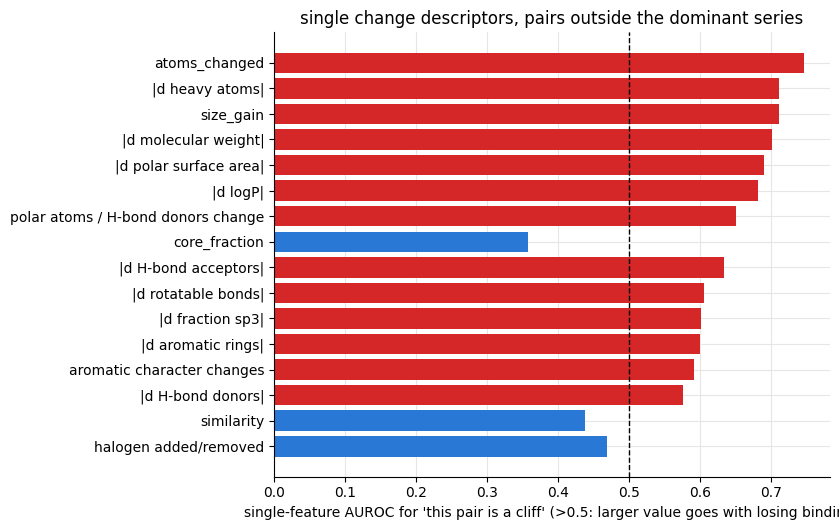

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
def feats(d):
    F=pd.DataFrame({"similarity":d.sim,"core_fraction":d.frac_core,"atoms_changed":d.a_diff_n+d.b_diff_n,"size_gain":(d.b_diff_n-d.a_diff_n).abs()})
    for p,l in PROPS: F["|d "+l+"|"]=d["dp_"+p].abs()
    for f,l in flags8[:3]: F[l]=d[f].astype(float)
    return F.fillna(F.median())
size_cols=["size_gain","atoms_changed","|d heavy atoms|","|d molecular weight|","|d logP|"]
lgm=lambda: make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000,C=0.3))
gbm=lambda: GradientBoostingClassifier(n_estimators=150,max_depth=2,learning_rate=0.05,subsample=0.8,random_state=0)
rows=[]
for part,dd in [("all pairs",C2),("without the dominant series",C2[~C2.big])]:
    F=feats(dd); y=(dd.kind=="cliff").astype(int).values; g=dd.series.values
    for mn,mk in [("logistic",lgm),("boosting",gbm)]:
        for fs,cols in [("all descriptors",list(F.columns)),("size + lipophilicity only",size_cols)]:
            pr=cross_val_predict(mk(),F[cols].values,y,cv=GroupKFold(5),groups=g,method="predict_proba")[:,1]
            rows.append((part,mn,fs,roc_auc_score(y,pr),len(y),int(y.sum()),len(np.unique(g))))
display(pd.DataFrame(rows,columns=["pairs used","model","features","AUROC (grouped by series)","pairs","cliffs","series"]).round(3))
dd=C2[~C2.big]; F=feats(dd); y=(dd.kind=="cliff").astype(int).values
sf=sorted([(c,roc_auc_score(y,F[c])) for c in F.columns],key=lambda t:abs(t[1]-0.5))
fig,ax=plt.subplots(figsize=(8.5,5.4)); ax.barh([c for c,_ in sf],[a for _,a in sf],color=[CL if a>0.5 else CO for _,a in sf])
ax.axvline(0.5,color=BLK,ls="--",lw=1); ax.set_xlabel("single-feature AUROC for 'this pair is a cliff' (>0.5: larger value goes with losing binding)")
ax.set_title("single change descriptors, pairs outside the dominant series"); plt.tight_layout(); plt.show()

## 10. Confidence in the cliff pairs
Boltz-2 confidence for the active versus its near-identical inactive, cliffs against the control's random-orientation spread. Median differences are small in absolute terms; read them with the size result in section 3b in mind.

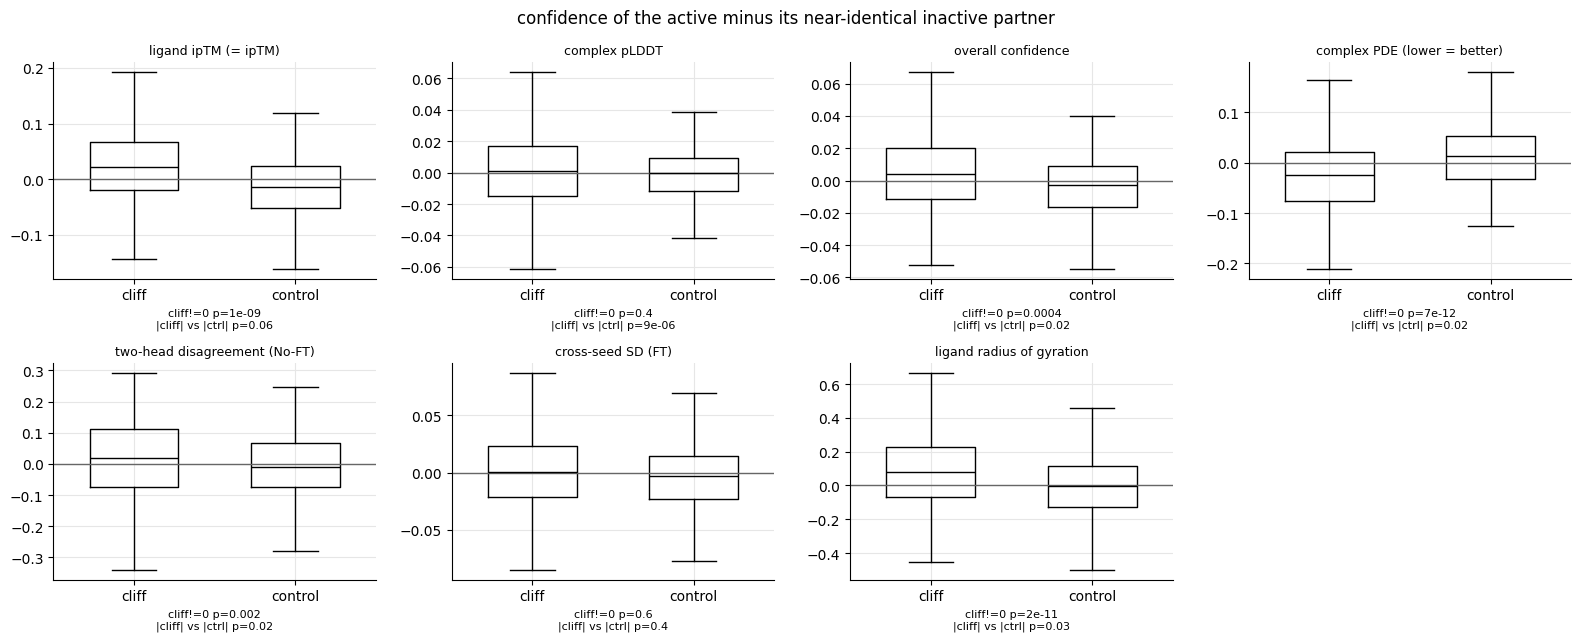

,median (active - inactive),p (delta != 0),p (|delta| cliff vs control)
signal,,,
ligand ipTM (= ipTM),0.0217,0.0000,0.0585
complex pLDDT,0.0008,0.3544,0.0000
overall confidence,0.0037,0.0004,0.0216
complex PDE (lower = better),-0.0245,0.0000,0.0175
two-head disagreement (No-FT),0.0200,0.0020,0.0179
cross-seed SD (FT),0.0001,0.5616,0.4489
ligand radius of gyration,0.0826,0.0000,0.0252


In [17]:
cf=[("ligand_iptm","ligand ipTM (= ipTM)"),("complex_plddt","complex pLDDT"),("confidence_score","overall confidence"),
    ("complex_pde","complex PDE (lower = better)"),("disagree_noft","two-head disagreement (No-FT)"),("cross_seed_sd","cross-seed SD (FT)"),("lig_rg","ligand radius of gyration")]
fig,axes=plt.subplots(2,4,figsize=(16,6.5)); rc=[]
for ax,(f,l) in zip(axes.ravel(),cf):
    if f=="lig_rg":
        a=(CLIFF.id_a.map(Mi.lig_rg)-CLIFF.id_b.map(Mi.lig_rg)).dropna(); b=(CTRL.id_a.map(Mi.lig_rg)-CTRL.id_b.map(Mi.lig_rg)).dropna()
    else: a=CLIFF["c_"+f].dropna(); b=CTRL["c_"+f].dropna()
    ax.boxplot([a,b],tick_labels=["cliff","control"],showfliers=False,widths=0.55,medianprops=dict(color=BLK)); ax.axhline(0,color=NEU,lw=1); ax.set_title(l,fontsize=9)
    try: pz_=stats.wilcoxon(a).pvalue
    except Exception: pz_=np.nan
    pu=stats.mannwhitneyu(a.abs(),b.abs()).pvalue
    ax.set_xlabel(f"cliff!=0 p={pz_:.1g}\n|cliff| vs |ctrl| p={pu:.1g}",fontsize=8); rc.append((l,a.median(),pz_,pu))
axes.ravel()[-1].axis("off")
fig.suptitle("confidence of the active minus its near-identical inactive partner",fontsize=12); plt.tight_layout(); plt.show()
display(pd.DataFrame(rc,columns=["signal","median (active - inactive)","p (delta != 0)","p (|delta| cliff vs control)"]).set_index("signal").round(4))

## 11. Does the confidence gap track the score gap?
Across cliff pairs, is a bigger ligand-ipTM difference associated with a bigger score difference? And when a model strongly prefers the inactive partner, is that pose confident?

Boltz-2 (dataset score): Spearman(ligand ipTM gap, score delta) rho=0.04 p=0.45
head-FT N=300: Spearman(ligand ipTM gap, score delta) rho=-0.02 p=0.74


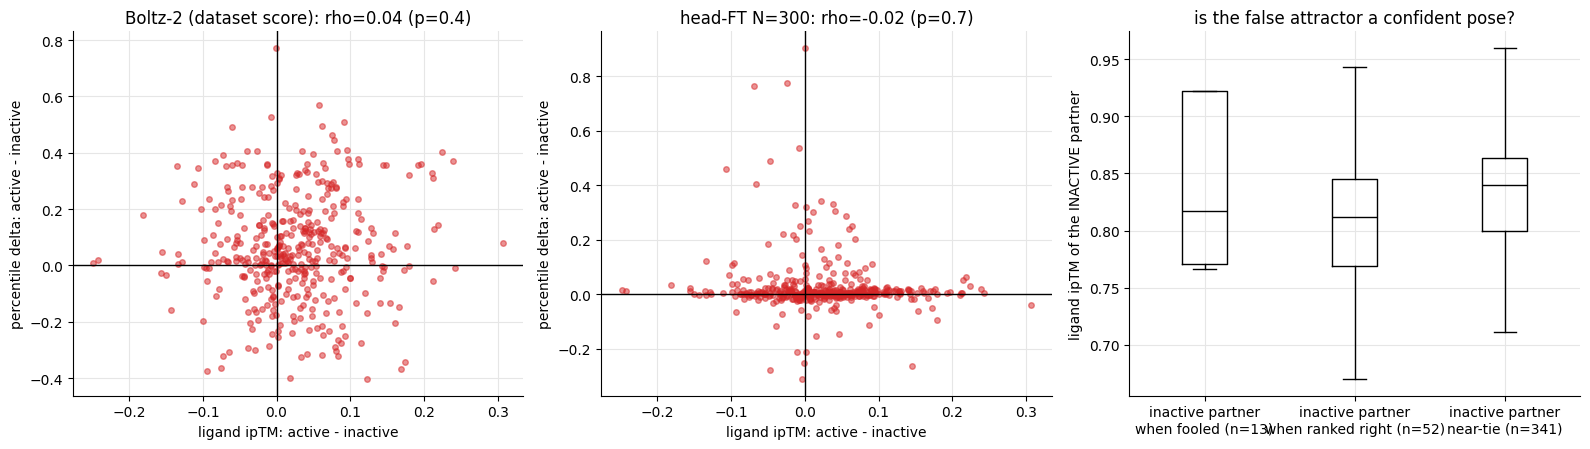

median ligand ipTM of the inactive partner: fooled 0.817 | ranked right 0.812 | near-tie 0.840


In [18]:
fig,axes=plt.subplots(1,3,figsize=(16,4.6))
for ax,(m,l) in zip(axes[:2],[("score_boltz2","Boltz-2 (dataset score)"),("ft300","head-FT N=300")]):
    d=CLIFF[["c_ligand_iptm","d_"+m]].dropna(); ax.scatter(d.c_ligand_iptm,d["d_"+m],s=16,alpha=0.5,color=CL); ax.axhline(0,color=BLK,lw=1); ax.axvline(0,color=BLK,lw=1)
    r,p=stats.spearmanr(d.c_ligand_iptm,d["d_"+m]); ax.set_title(f"{l}: rho={r:.2f} (p={p:.1g})")
    ax.set_xlabel("ligand ipTM: active - inactive"); ax.set_ylabel("percentile delta: active - inactive"); print(f"{l}: Spearman(ligand ipTM gap, score delta) rho={r:.2f} p={p:.2g}")
fool=CLIFF[CLIFF.d_score_boltz2<-0.3]; ok=CLIFF[CLIFF.d_score_boltz2>0.3]; mid=CLIFF[CLIFF.d_score_boltz2.abs()<=0.3]
vals=[(f"inactive partner\nwhen fooled (n={len(fool)})",fool.id_b.map(Mi.ligand_iptm)),(f"inactive partner\nwhen ranked right (n={len(ok)})",ok.id_b.map(Mi.ligand_iptm)),(f"inactive partner\nnear-tie (n={len(mid)})",mid.id_b.map(Mi.ligand_iptm))]
axes[2].boxplot([v.dropna() for _,v in vals],tick_labels=[l for l,_ in vals],showfliers=False,medianprops=dict(color=BLK))
axes[2].set_ylabel("ligand ipTM of the INACTIVE partner"); axes[2].set_title("is the false attractor a confident pose?")
plt.tight_layout(); plt.show()
print("median ligand ipTM of the inactive partner: fooled %.3f | ranked right %.3f | near-tie %.3f"%tuple(v.median() for _,v in vals))

## 12. Did the pose change? Contact profiles of the pair
Each pose's per-residue minimum distance to the ligand gives a contact set (residues within 5 A). Dissimilarity = 1 - Jaccard overlap. The distribution is bimodal: a large share of pairs share no contact residues at all. That is common among near-identical *actives* too, which is itself a finding about how stable the placement of a scaffold is.

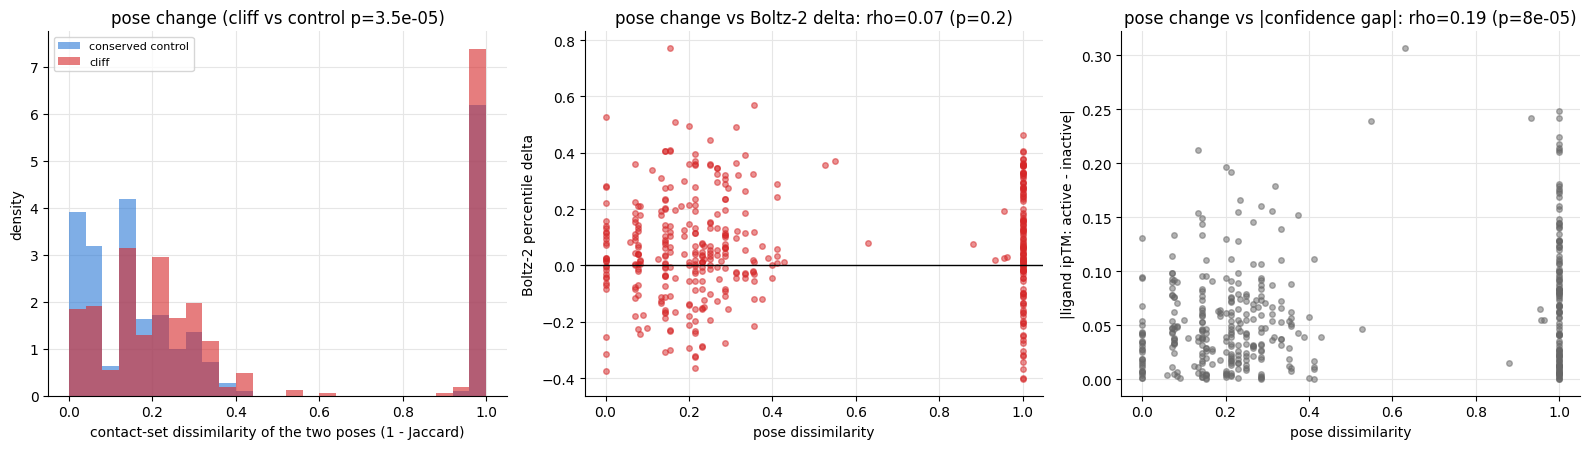

pairs sharing NO contact residue: cliffs 119/406 (29%) vs controls 68/275 (25%); Fisher p=0.22, odds ratio 1.26


In [19]:
fig,axes=plt.subplots(1,3,figsize=(16,4.6)); b=np.linspace(0,1,26)
axes[0].hist(CTRL.pose_jdist.dropna(),bins=b,color=CO,alpha=0.6,density=True,label="conserved control"); axes[0].hist(CLIFF.pose_jdist.dropna(),bins=b,color=CL,alpha=0.6,density=True,label="cliff")
pu=stats.mannwhitneyu(CLIFF.pose_jdist.dropna(),CTRL.pose_jdist.dropna()).pvalue
axes[0].set_xlabel("contact-set dissimilarity of the two poses (1 - Jaccard)"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=8); axes[0].set_title(f"pose change (cliff vs control p={pu:.2g})")
d=CLIFF[["pose_jdist","d_score_boltz2"]].dropna(); axes[1].scatter(d.pose_jdist,d.d_score_boltz2,s=16,alpha=0.5,color=CL); axes[1].axhline(0,color=BLK,lw=1)
r,p=stats.spearmanr(d.pose_jdist,d.d_score_boltz2); axes[1].set_title(f"pose change vs Boltz-2 delta: rho={r:.2f} (p={p:.1g})"); axes[1].set_xlabel("pose dissimilarity"); axes[1].set_ylabel("Boltz-2 percentile delta")
d2=CLIFF[["pose_jdist","c_ligand_iptm"]].dropna(); axes[2].scatter(d2.pose_jdist,d2.c_ligand_iptm.abs(),s=16,alpha=0.5,color=NEU)
r2,p2=stats.spearmanr(d2.pose_jdist,d2.c_ligand_iptm.abs()); axes[2].set_title(f"pose change vs |confidence gap|: rho={r2:.2f} (p={p2:.1g})"); axes[2].set_xlabel("pose dissimilarity"); axes[2].set_ylabel("|ligand ipTM: active - inactive|")
plt.tight_layout(); plt.show()
sc=(CLIFF.pose_jdist>=0.99).sum(); so=(CTRL.pose_jdist>=0.99).sum()
odds,pf=stats.fisher_exact([[sc,len(CLIFF)-sc],[so,len(CTRL)-so]])
print(f"pairs sharing NO contact residue: cliffs {sc}/{len(CLIFF)} ({100*sc/len(CLIFF):.0f}%) vs controls {so}/{len(CTRL)} ({100*so/len(CTRL):.0f}%); Fisher p={pf:.2g}, odds ratio {odds:.2f}")

## 13. Where along the protein do the two poses differ?
Mean absolute change in each residue's ligand distance between the two members, along the full sequence, for cliffs and controls. Note that residue 275 is the C-terminal His-tag end of the 588689 construct, so the largest value there most likely reflects tag flexibility rather than pocket chemistry.

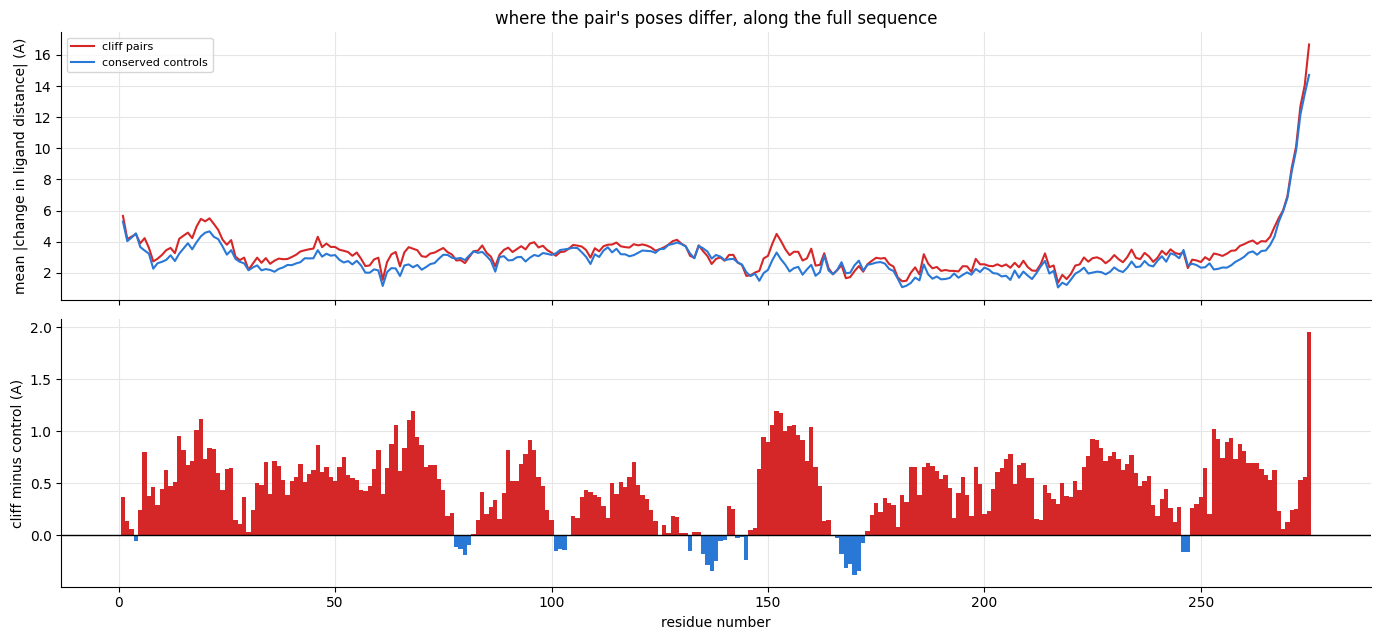

residues where cliff poses differ most beyond controls: 275(+1.96A), 68(+1.20A), 152(+1.19A), 153(+1.18A), 19(+1.12A), 67(+1.11A), 64(+1.06A), 156(+1.06A)
mean over residues: cliff 3.34 A vs control 2.90 A


In [20]:
dc=np.nanmean(np.abs(ma-mb)[(P.kind=="cliff").values],axis=0); dn=np.nanmean(np.abs(ma-mb)[(P.kind=="conserved").values],axis=0)
res_num=np.arange(1,len(dc)+1); fig,axes=plt.subplots(2,1,figsize=(14,6.5),sharex=True)
axes[0].plot(res_num,dc,color=CL,label="cliff pairs"); axes[0].plot(res_num,dn,color=CO,label="conserved controls")
axes[0].set_ylabel("mean |change in ligand distance| (A)"); axes[0].legend(fontsize=8); axes[0].set_title("where the pair's poses differ, along the full sequence")
diff=dc-dn; axes[1].bar(res_num,diff,width=1.0,color=np.where(diff>0,CL,CO)); axes[1].axhline(0,color=BLK,lw=1); axes[1].set_xlabel("residue number"); axes[1].set_ylabel("cliff minus control (A)")
plt.tight_layout(); plt.show()
top=np.argsort(-diff)[:8]; print("residues where cliff poses differ most beyond controls:", ", ".join(f"{i+1}({diff[i]:+.2f}A)" for i in top))
print(f"mean over residues: cliff {np.nanmean(dc):.2f} A vs control {np.nanmean(dn):.2f} A")

## 14. Pose site: do cliff pairs switch binding sites?
Clustering each member's contact profile into two sites (k-means) asks whether the two molecules of a pair sit in the same site, and whether a site switch goes with a large score delta.

,cliff,control
share that switch site,0.099,0.131
pairs,406.000,275.000


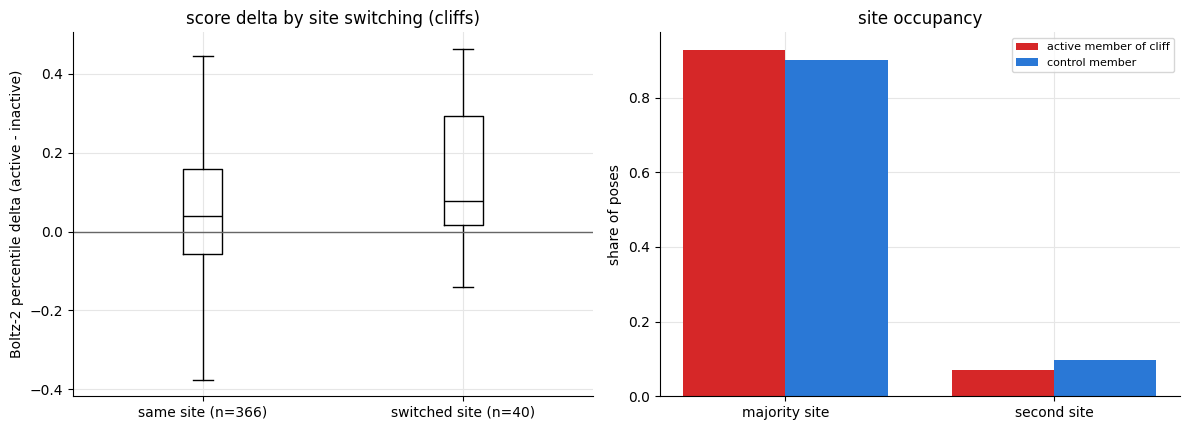

Boltz-2 delta, same site vs switched: median 0.04 vs 0.08 (MWU p=0.005)


In [21]:
from sklearn.cluster import KMeans
allC=(MD<=5.0).astype(float); okr=~np.isnan(MD).any(1)
km=KMeans(2,n_init=10,random_state=0).fit(allC[okr]); lab=np.full(len(MD),-1); lab[okr]=km.labels_
big=np.bincount(km.labels_).argmax(); lab=np.where(lab==big,0,np.where(lab>=0,1,-1))
P["site_a"]=[lab[rowof[i]] for i in P.id_a]; P["site_b"]=[lab[rowof[i]] for i in P.id_b]
P["switch"]=(P.site_a!=P.site_b)&(P.site_a>=0)&(P.site_b>=0)
CLIFF=P[P.kind=="cliff"].copy(); CTRL=P[P.kind=="conserved"].copy()
display(pd.DataFrame({"cliff":[CLIFF.switch.mean(),len(CLIFF)],"control":[CTRL.switch.mean(),len(CTRL)]},index=["share that switch site","pairs"]).round(3))
fig,axes=plt.subplots(1,2,figsize=(12,4.4)); g=[CLIFF[~CLIFF.switch].d_score_boltz2.dropna(),CLIFF[CLIFF.switch].d_score_boltz2.dropna()]
axes[0].boxplot(g,tick_labels=[f"same site (n={len(g[0])})",f"switched site (n={len(g[1])})"],showfliers=False,medianprops=dict(color=BLK))
axes[0].axhline(0,color=NEU,lw=1); axes[0].set_ylabel("Boltz-2 percentile delta (active - inactive)"); axes[0].set_title("score delta by site switching (cliffs)")
share=[[(P[(P.kind==k)].site_a==s).mean() for s in (0,1)] for k in ("cliff","conserved")]; x=np.arange(2)
axes[1].bar(x-0.19,share[0],0.38,color=CL,label="active member of cliff"); axes[1].bar(x+0.19,share[1],0.38,color=CO,label="control member")
axes[1].set_xticks(x); axes[1].set_xticklabels(["majority site","second site"]); axes[1].set_ylabel("share of poses"); axes[1].legend(fontsize=8); axes[1].set_title("site occupancy")
plt.tight_layout(); plt.show()
print("Boltz-2 delta, same site vs switched: median %.2f vs %.2f (MWU p=%.2g)"%(g[0].median(),g[1].median(),stats.mannwhitneyu(g[0],g[1]).pvalue))

## 15. Candidate explanations, compared with the controls
Each observable difference is applied identically to cliffs and to controls. What matters is whether it is *more common among cliffs than among near-identical pairs that both bind*. Odds ratios and Fisher exact tests give that. Flags overlap (a pair can carry several), and these are associations - nothing here is a controlled experiment, so none is proven to cause the loss.

,share of cliffs,share of controls,odds ratio,Fisher p
observable difference,,,,
pose shares no contact residue,0.293,0.247,1.262,0.221
large ligand-ipTM gap (control 90th pct),0.133,0.102,1.353,0.232
polar atoms / H-bond donors change,0.283,0.160,2.075,0.000
fragment size differs by 3+ atoms,0.266,0.102,3.197,0.000
inactive is smaller (>= 1 heavy atom),0.525,0.324,2.306,0.000
inactive is less lipophilic (>= 0.5 logP),0.502,0.156,5.449,0.000
inactive is lighter (>= 20 Da),0.562,0.265,3.544,0.000
same molecular formula (regioisomer),0.022,0.087,0.237,0.000
single-atom swap (<=1 atom differs on each side),0.131,0.305,0.341,0.000


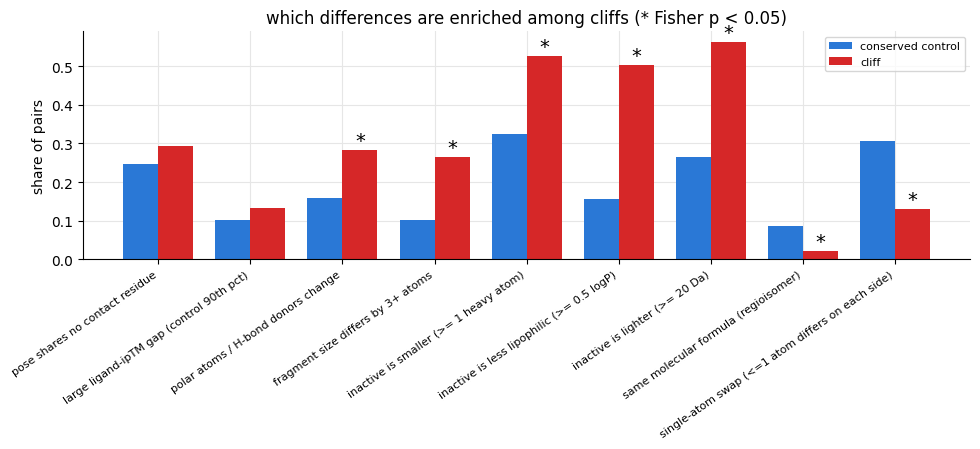

In [22]:
q_conf=CTRL.c_ligand_iptm.abs().quantile(0.9)
def flag_table(df):
    f=pd.DataFrame(index=df.index)
    f["pose shares no contact residue"]=df.pose_jdist>=0.99
    f["large ligand-ipTM gap (control 90th pct)"]=df.c_ligand_iptm.abs()>=q_conf
    f["polar atoms / H-bond donors change"]=(df.a_diff_hbd!=df.b_diff_hbd)|((df.a_diff_has_N+df.a_diff_has_O)!=(df.b_diff_has_N+df.b_diff_has_O))
    f["fragment size differs by 3+ atoms"]=(df.b_diff_n-df.a_diff_n).abs()>=3
    f["inactive is smaller (>= 1 heavy atom)"]=df.dp_heavy>=1
    f["inactive is less lipophilic (>= 0.5 logP)"]=df.dp_logP>=0.5
    f["inactive is lighter (>= 20 Da)"]=df.dp_MW>=20
    f["same molecular formula (regioisomer)"]=df.dp_MW.abs()<0.01
    f["single-atom swap (<=1 atom differs on each side)"]=(df.a_diff_n<=1)&(df.b_diff_n<=1)
    return f
XC=P[(P.kind=="cliff")&(P.mcs_ok==1)].copy(); XK=P[(P.kind=="conserved")&(P.mcs_ok==1)].copy()
FC=flag_table(XC); FK=flag_table(XK); rows=[]
for c in FC.columns:
    a,b=int(FC[c].sum()),int(FK[c].sum()); odds,pf=stats.fisher_exact([[a,len(FC)-a],[b,len(FK)-b]])
    rows.append((c,a/len(FC),b/len(FK),odds,pf))
FT_=pd.DataFrame(rows,columns=["observable difference","share of cliffs","share of controls","odds ratio","Fisher p"]).set_index("observable difference")
display(FT_.round(3))
fig,ax=plt.subplots(figsize=(10,4.6)); x=np.arange(len(FT_)); w=0.38
ax.bar(x-w/2,FT_["share of controls"],w,color=CO,label="conserved control"); ax.bar(x+w/2,FT_["share of cliffs"],w,color=CL,label="cliff")
ax.set_xticks(x); ax.set_xticklabels(FT_.index,rotation=35,ha="right",fontsize=8); ax.set_ylabel("share of pairs"); ax.legend(fontsize=8)
for i,(_,r) in enumerate(FT_.iterrows()):
    if r["Fisher p"]<0.05: ax.text(i+w/2,r["share of cliffs"],"*",ha="center",va="bottom",fontsize=14)
ax.set_title("which differences are enriched among cliffs (* Fisher p < 0.05)"); plt.tight_layout(); plt.show()

**Robustness across partitions.** The same comparison for all pairs, without the dominant series, and inside it. Each cell is share of cliffs vs share of controls, then the odds ratio and Fisher p (optimistic, see the note at the top).

In [23]:
parts=[("all pairs",XC,XK),("without the dominant series",XC[~XC.big],XK[~XK.big]),("dominant series only",XC[XC.big],XK[XK.big])]
rows=[]
for c in FC.columns:
    r={"observable difference":c}
    for nm,dc,dk in parts:
        fc=flag_table(dc)[c]; fk=flag_table(dk)[c]; a,b=int(fc.sum()),int(fk.sum())
        o,p=stats.fisher_exact([[a,len(fc)-a],[b,len(fk)-b]]); r[f"{nm} (n={len(dc)} vs {len(dk)})"]=f"{fc.mean():.2f} vs {fk.mean():.2f}, OR {o:.1f}, p={p:.1g}"
    rows.append(r)
display(pd.DataFrame(rows).set_index("observable difference"))

,all pairs (n=406 vs 275),without the dominant series (n=154 vs 196),dominant series only (n=252 vs 79)
observable difference,,,
pose shares no contact residue,"0.29 vs 0.25, OR 1.3, p=0.2","0.16 vs 0.12, OR 1.4, p=0.4","0.37 vs 0.56, OR 0.5, p=0.006"
large ligand-ipTM gap (control 90th pct),"0.13 vs 0.10, OR 1.4, p=0.2","0.10 vs 0.07, OR 1.4, p=0.4","0.15 vs 0.18, OR 0.9, p=0.6"
polar atoms / H-bond donors change,"0.28 vs 0.16, OR 2.1, p=0.0002","0.53 vs 0.22, OR 3.8, p=7e-09","0.13 vs 0.00, OR inf, p=7e-05"
fragment size differs by 3+ atoms,"0.27 vs 0.10, OR 3.2, p=9e-08","0.40 vs 0.10, OR 6.1, p=4e-11","0.19 vs 0.11, OR 1.8, p=0.2"
inactive is smaller (>= 1 heavy atom),"0.52 vs 0.32, OR 2.3, p=2e-07","0.60 vs 0.32, OR 3.3, p=9e-08","0.48 vs 0.34, OR 1.8, p=0.04"
inactive is less lipophilic (>= 0.5 logP),"0.50 vs 0.16, OR 5.4, p=3e-21","0.44 vs 0.14, OR 4.9, p=3e-10","0.54 vs 0.20, OR 4.6, p=1e-07"
inactive is lighter (>= 20 Da),"0.56 vs 0.27, OR 3.5, p=1e-14","0.46 vs 0.20, OR 3.4, p=3e-07","0.62 vs 0.43, OR 2.2, p=0.003"
same molecular formula (regioisomer),"0.02 vs 0.09, OR 0.2, p=0.0002","0.02 vs 0.12, OR 0.1, p=0.0004","0.02 vs 0.01, OR 1.9, p=1"
single-atom swap (<=1 atom differs on each side),"0.13 vs 0.31, OR 0.3, p=4e-08","0.12 vs 0.37, OR 0.2, p=1e-07","0.13 vs 0.14, OR 1.0, p=1"


## 16. Who detects which kind of cliff?
For cliff pairs carrying each observable difference, the share where each signal ranks the active higher. The right-most column is the 'larger molecule' baseline for reference; it is 1.00 in the row defined by the inactive being smaller, by construction. GNINA and Vina exist for only about a third of pairs and are averaged over those. Several rows are small, so treat single cells with caution.

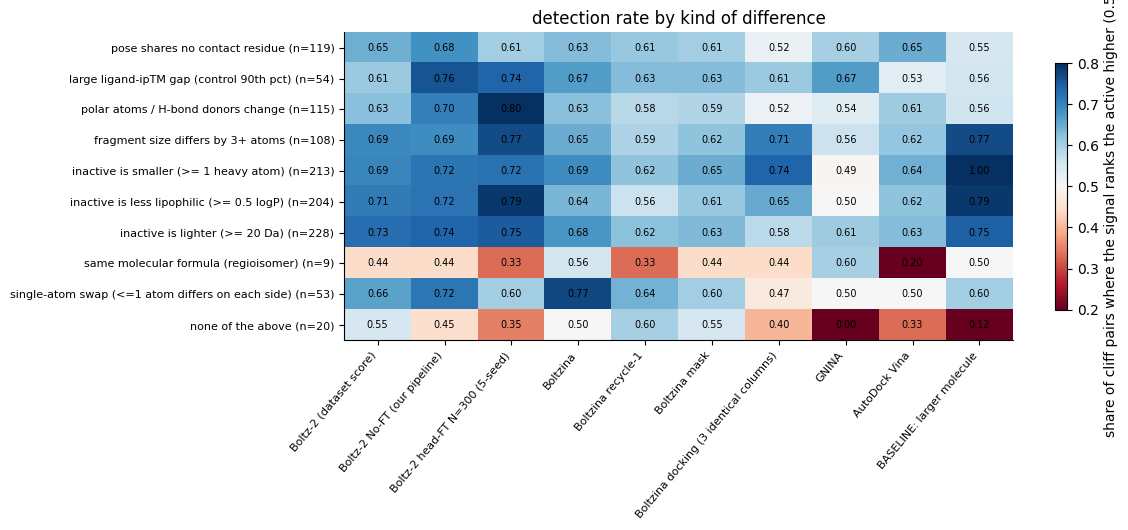

,Boltz-2 (dataset score),Boltz-2 No-FT (our pipeline),Boltz-2 head-FT N=300 (5-seed),Boltzina,Boltzina recycle-1,Boltzina mask,Boltzina docking (3 identical columns),GNINA,AutoDock Vina,BASELINE: larger molecule
pose shares no contact residue (n=119),0.65,0.68,0.61,0.63,0.61,0.61,0.52,0.60,0.65,0.55
large ligand-ipTM gap (control 90th pct) (n=54),0.61,0.76,0.74,0.67,0.63,0.63,0.61,0.67,0.53,0.56
polar atoms / H-bond donors change (n=115),0.63,0.70,0.80,0.63,0.58,0.59,0.52,0.54,0.61,0.56
fragment size differs by 3+ atoms (n=108),0.69,0.69,0.77,0.65,0.59,0.62,0.71,0.56,0.62,0.77
inactive is smaller (>= 1 heavy atom) (n=213),0.69,0.72,0.72,0.69,0.62,0.65,0.74,0.49,0.64,1.00
inactive is less lipophilic (>= 0.5 logP) (n=204),0.71,0.72,0.79,0.64,0.56,0.61,0.65,0.50,0.62,0.79
inactive is lighter (>= 20 Da) (n=228),0.73,0.74,0.75,0.68,0.62,0.63,0.58,0.61,0.63,0.75
same molecular formula (regioisomer) (n=9),0.44,0.44,0.33,0.56,0.33,0.44,0.44,0.60,0.20,0.50
single-atom swap (<=1 atom differs on each side) (n=53),0.66,0.72,0.60,0.77,0.64,0.60,0.47,0.50,0.50,0.60
none of the above (n=20),0.55,0.45,0.35,0.50,0.60,0.55,0.40,0.00,0.33,0.12


In [24]:
def rate(x):
    x=x.dropna(); return ((x>0).sum()+0.5*(x==0).sum())/len(x) if len(x) else np.nan
cols=[(m,l) for m,l in MODS]; rowsH=[]; lab_rows=[]
for c in list(FC.columns)+["none of the above"]:
    mask=(~FC.any(axis=1)) if c=="none of the above" else FC[c]
    s=XC[mask.values]; rowsH.append([rate(s["d_"+m]) for m,_ in cols]+[rate(s.dp_heavy)]); lab_rows.append(f"{c} (n={len(s)})")
mat=np.array(rowsH,float); names=[l for _,l in cols]+["BASELINE: larger molecule"]
fig,ax=plt.subplots(figsize=(12,5.4)); im=ax.imshow(mat,cmap="RdBu",vmin=0.2,vmax=0.8,aspect="auto"); ax.grid(False)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=50,ha="right",fontsize=8); ax.set_yticks(range(len(lab_rows))); ax.set_yticklabels(lab_rows,fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if np.isfinite(mat[i,j]): ax.text(j,i,f"{mat[i,j]:.2f}",ha="center",va="center",fontsize=7)
fig.colorbar(im,ax=ax,shrink=0.8,label="share of cliff pairs where the signal ranks the active higher (0.5 = blind)")
ax.set_title("detection rate by kind of difference"); plt.tight_layout(); plt.show()
display(pd.DataFrame(mat,index=lab_rows,columns=names).round(2))

## 17. One example per enriched difference
The most similar cliff for each of the three differences most enriched among cliffs, drawn with the changed atoms highlighted.

difference: inactive is less lipophilic (>= 0.5 logP)


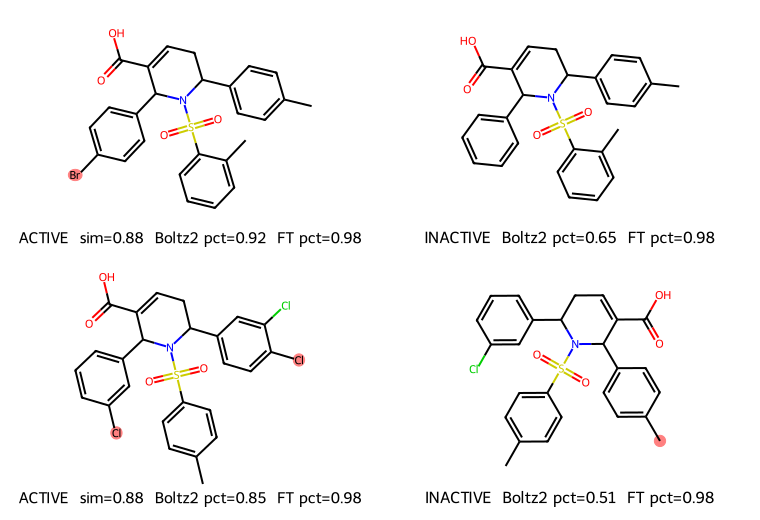

difference: inactive is lighter (>= 20 Da)


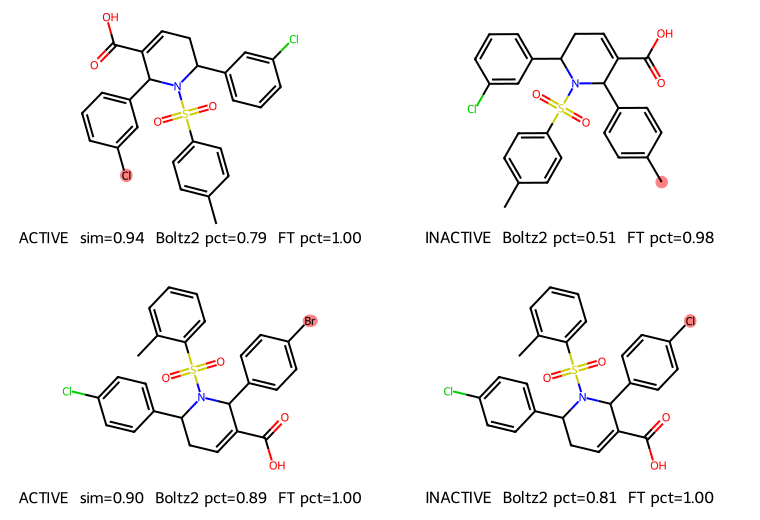

difference: fragment size differs by 3+ atoms


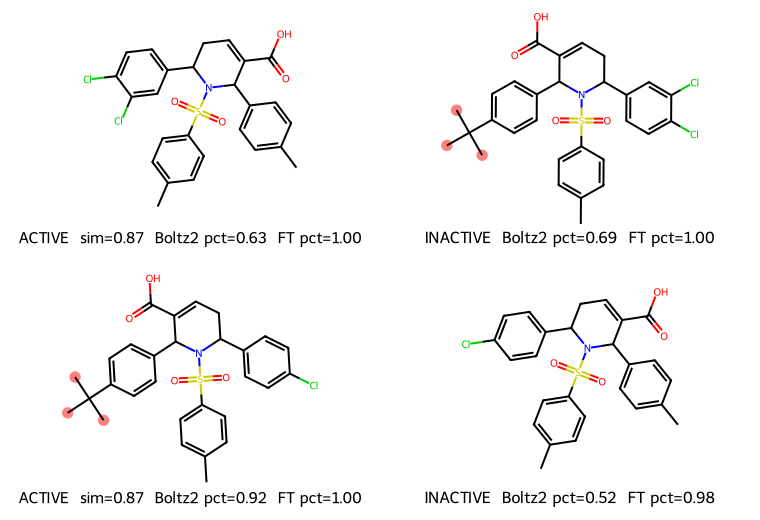

In [25]:
top3=FT_[FT_["Fisher p"]<0.1].sort_values("odds ratio",ascending=False).head(3).index.tolist() or list(FT_.sort_values("odds ratio",ascending=False).head(3).index)
for c in top3:
    s=XC[FC[c].values].sort_values("sim",ascending=False)
    if len(s): draw_pairs(s,2,f"difference: {c}")

## Conclusions (target 588689)

There are 406 cliff pairs and 275 conserved controls, but a single series of 52 compounds supplies 62% of the cliff pairs, so each result below is given for all pairs, without that series, and inside it where the answer differs. Everything is an association in observational pairs, and p-values treat pairs as independent, so they are optimistic.

**1. The models mostly do not separate near-identical siblings.** Among pairs with Tanimoto >= 0.7 (151, of which 103 are in the dominant series), the two members get percentile scores within +/-0.3 of each other in 86% of pairs for Boltz-2 and 99% for head-FT (98% and 98% outside the dominant series, 81% and 100% inside it). Where Boltz-2 or the No-FT score do separate a pair they are mostly right (dominant series: Boltz-2 17 right against 3 wrong, No-FT 24 against 5). Head-FT rarely separates them in percentile terms (0 of 103 in the dominant series), but that is partly a property of the percentile scale: fine-tuning places whole series near the top of the ranking, so the percentile gap between two members is small even when their order is right. With each model's 'large' threshold calibrated on both-active pairs, head-FT's sensitivity is within noise of No-FT's (notebook 16). Docking-derived scores separate more pairs but less reliably (Boltzina docking: 25 right, 16 wrong overall).

**2. There is no reliable evidence that any model reads the edit beyond size and lipophilicity.** Ranking the active above its inactive partner, all pairs: Boltz-2 0.65, No-FT 0.67, head-FT 0.66, against 0.64 for 'larger molecule', 0.72 for 'heavier' and 0.72 for 'more lipophilic'. Without the dominant series the models are 0.67-0.70 and the baselines 0.64-0.67; inside it the models are 0.62-0.68 and the baselines reach 0.78. All intervals overlap, so no ordering can be claimed. The baseline direction is justified on the whole library (AUROC: logP 0.66, MW 0.59, heavy atoms 0.59), not from these pairs. When the active is the smaller molecule the scoring models fall to 0.52-0.58 (96 pairs). Library-wide the models reach AUROC 0.91-0.93 but within a near-identical pair about 0.65, and head-FT's 2x AP gain over No-FT (notebook 08) is not visible here in ranking accuracy, which does not depend on the score scale (0.66 vs 0.67 all pairs, 0.70 vs 0.67 without the dominant series): the gain comes from ranking series against each other, not from telling siblings apart.

**3. What differs in pairs that lose binding is mostly subtraction of lipophilic bulk.** Against both-active controls, the inactive partner is more often less lipophilic (>= 0.5 logP), lighter (>= 20 Da) and smaller than the active, and the direction and size hold in both partitions (less lipophilic: odds ratio 4.9 outside the dominant series, 4.6 inside; lighter 3.4 and 2.2; smaller 3.3 and 1.8). Outside the dominant series there are also larger edits (3+ atoms, OR 6.1) and polar-atom changes (OR 3.8), while single-atom swaps (12% of cliffs vs 37% of controls) and regioisomers (2% vs 12%) are under-represented, so small substitutions are usually tolerated. Inside the dominant series single-atom swaps are as common among cliffs as among controls (13% vs 14%): that series is steep enough that even a Cl for CH3 swap can flip the outcome, as the gallery shows. With cross-validation grouped by series, cliff-versus-control is predictable from structure at AUROC 0.70-0.74 outside the dominant series (size and lipophilicity alone 0.73-0.74, as good as all descriptors) but only 0.52-0.60 across all pairs. Part of this is the general trend that larger, greasier compounds hit more often across the library, which a pair design cannot fully remove.

**4. Confidence does not track the cliffs in general.** The active is slightly more confident than its inactive partner (ligand ipTM +0.02, PDE 0.02 lower), and ligand ipTM and low PDE pick the active in 63% and 65% of all pairs. That is series-specific: 57% and 54% outside the dominant series, 67% and 71% inside it. The confidence gap is unrelated to the size of the score delta (Spearman 0.04 and -0.02), and inactive partners the models prefer are as confident as any other (ligand ipTM 0.82 vs 0.81). pLDDT and overall confidence carry no signal.

**5. The pose does not explain it.** Pairs sharing no contact residue are 29% of cliffs and 25% of controls (p=0.22); outside the dominant series 16% vs 12% (p=0.4), and inside it the direction reverses (37% vs 56%). Site switching is no more common among cliffs (10% vs 13%). Cliff poses differ slightly more overall (mean 3.3 vs 2.9 A per residue), most at residues 64-68, 152-156 and 19, next to the two binding regions in notebook 13. That a quarter of near-identical *actives* are also placed with no shared contact is a caution for any pose-based score.

**6. The loss is not always complete.** Counting each of the 154 distinct inactive partners once, the median screen Z-score is 0.45 against -0.05 for ordinary inactives; 19% sit above the 99th percentile of ordinary inactives (1% expected) and 2% reach the level of the weakest actives. Whether the models track this graded readout is inconclusive: head-FT rho is +0.18 overall, 0.05 outside the dominant series and 0.33 inside it; Boltz-2 is +0.04 overall.

**7. Cost at the top of the ranking.** Cliff siblings of true actives are over-represented among the false positives in the top 1%: 1.9% of No-FT's (6x more than ordinary compounds) and 2.4% of Boltz-2's (7.6x), and 7.8% of head-FT's (25x), but 14 of head-FT's 29 come from the dominant series; without it head-FT is at 4.0% (13x). In absolute terms they are a minority of the false positives, and this counts only siblings of the 396 held-out actives at Tanimoto >= 0.6, so it is a lower bound.

**Caveats.** One target. The pair set is anchored on actives, so it says what distinguishes an inactive neighbour of an active and nothing about inactive-inactive pairs. Labels come from a single-concentration primary screen with a graded readout, so some cliffs are assay noise (see 6). The property-matched subset has 29 pairs, too few to conclude anything, and several cells in the detection table are small (regioisomers 9, no-flag 20). GNINA and Vina exist for only about a third of pairs.